# High throughput Machine Learning Model for Perfume Prediction and Perfume Design
# IHPC


https://github.com/WillKoehrsen/Machine-Learning-Projects/blob/master/Feature%20Selection.ipynb

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


#Library

In [ ]:
'''
Plotting libraries
'''
import pandas as pd
import matplotlib.cm as cm
#from matplotlib import pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, classification_report, confusion_matrix
from sklearn.metrics import roc_auc_score
from sklearn.decomposition import PCA
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import silhouette_samples, silhouette_score
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.cluster import KMeans
from sklearn import datasets, decomposition
from sklearn.manifold import TSNE
from sklearn.metrics import make_scorer
from sklearn.feature_selection import VarianceThreshold
from sklearn.feature_selection import RFE
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.datasets import make_classification



https://onlinelibrary.wiley.com/doi/10.1002/jcc.21707

https://machinelearningmastery.com/data-preparation-without-data-leakage/

In [ ]:
!pip install joblib
!pip install RDKit

In [ ]:
!pip install iterative-stratification
!pip install feature-engine

Restart runtime

In [ ]:
from feature_engine.selection import DropCorrelatedFeatures

Font type

In [ ]:
## this for Font type
!cp /content/drive/MyDrive/DOS_0.25n/Helvetica-Font/Helvetica.ttf /usr/local/lib/python3.10/dist-packages/matplotlib/mpl-data/fonts/ttf

from matplotlib.font_manager import FontProperties
from matplotlib.ticker import (MultipleLocator, AutoMinorLocator)
import matplotlib.pyplot as plt
# Helvetica-Font change fname=r'/Helvetica-Font/Helvetica.ttf'
myfont = FontProperties(fname=r'/usr/local/lib/python3.10/dist-packages/matplotlib/mpl-data/fonts/ttf/Helvetica.ttf',size=20)

Data with CID for tract CID( if need)

In [ ]:

#label=pd.read_csv('/content/drive/MyDrive/pgml/Data analysis/common/update17jan/train/label_502.csv')
#Feature_1901=pd.read_csv('/content/drive/MyDrive/pgml/Data analysis/common/update17jan/feature_1901.csv')

UsageError: Line magic function `%label=pd.read_csv('/content/drive/MyDrive/pgml/Data` not found.


In [ ]:
## split data for multi label data
# if want to run just romove the %
#from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit
#msss = MultilabelStratifiedShuffleSplit(n_splits=10, test_size=0.25, random_state=0)
#
#for train_index, test_index in msss.split(Feature_1901, label):
#   #print("TRAIN:", train_index, "TEST:", test_index)
#   X_train_cid, X_test_cid = Feature_1901.loc[train_index], Feature_1901.loc[test_index]
#   y_train_cid, y_test_cid = label.loc[train_index], label.loc[test_index]

UsageError: Line magic function `%` not found.


In [ ]:
### if want to run just romove the %
#y_train_cid.to_csv('y_train_2103.csv', index=False)
#y_test_cid.to_csv('y_test_2103.csv', index=False)
#X_train_cid.to_csv('X_train_2103.csv', index=False)
#X_test_cid.to_csv('X_test_2103.csv', index=False)

# Run code from here

# Data loading


Label

In [ ]:
# label
label=pd.read_csv('/content/drive/MyDrive/pgml/Data analysis/common/update17jan/train/label_502.csv')
#label=pd.read_csv(path+'com_label_169.csv')
label=label.drop(columns=['CommonCID'])
y=label

Word Clond

<Figure size 1000x500 with 0 Axes>

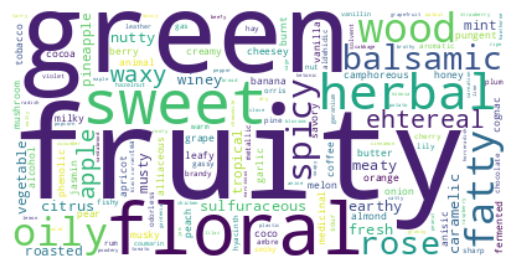

In [ ]:
from wordcloud import WordCloud
from wordcloud import WordCloud, ImageColorGenerator

nonzero_counts = label.apply(lambda col: (col != 0).sum())
label_a = label.loc[:, nonzero_counts >= 2]
word_frequencies = label_a.sum().to_dict()
# Combine all text entries into a single string
text_combined = ' '.join(label_a.columns)
#bubble_mask = imageio.imread(r"/content/Top-Anecdotal-signs-of-a-market-bubble-1.png")
#mask = np.array(bubble_mask)
#plt.imshow(bubble_mask)
# Generate the word cloud
wordcloud = WordCloud( mode='RGB',random_state = 42,background_color='white',contour_width=1, contour_color='steelblue').generate_from_frequencies(word_frequencies)

# Display the generated word cloud
plt.figure(figsize=(10, 5))
plt.figure()
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
# store to file
#plt.savefig("twitter.png", format="png")
plt.show()

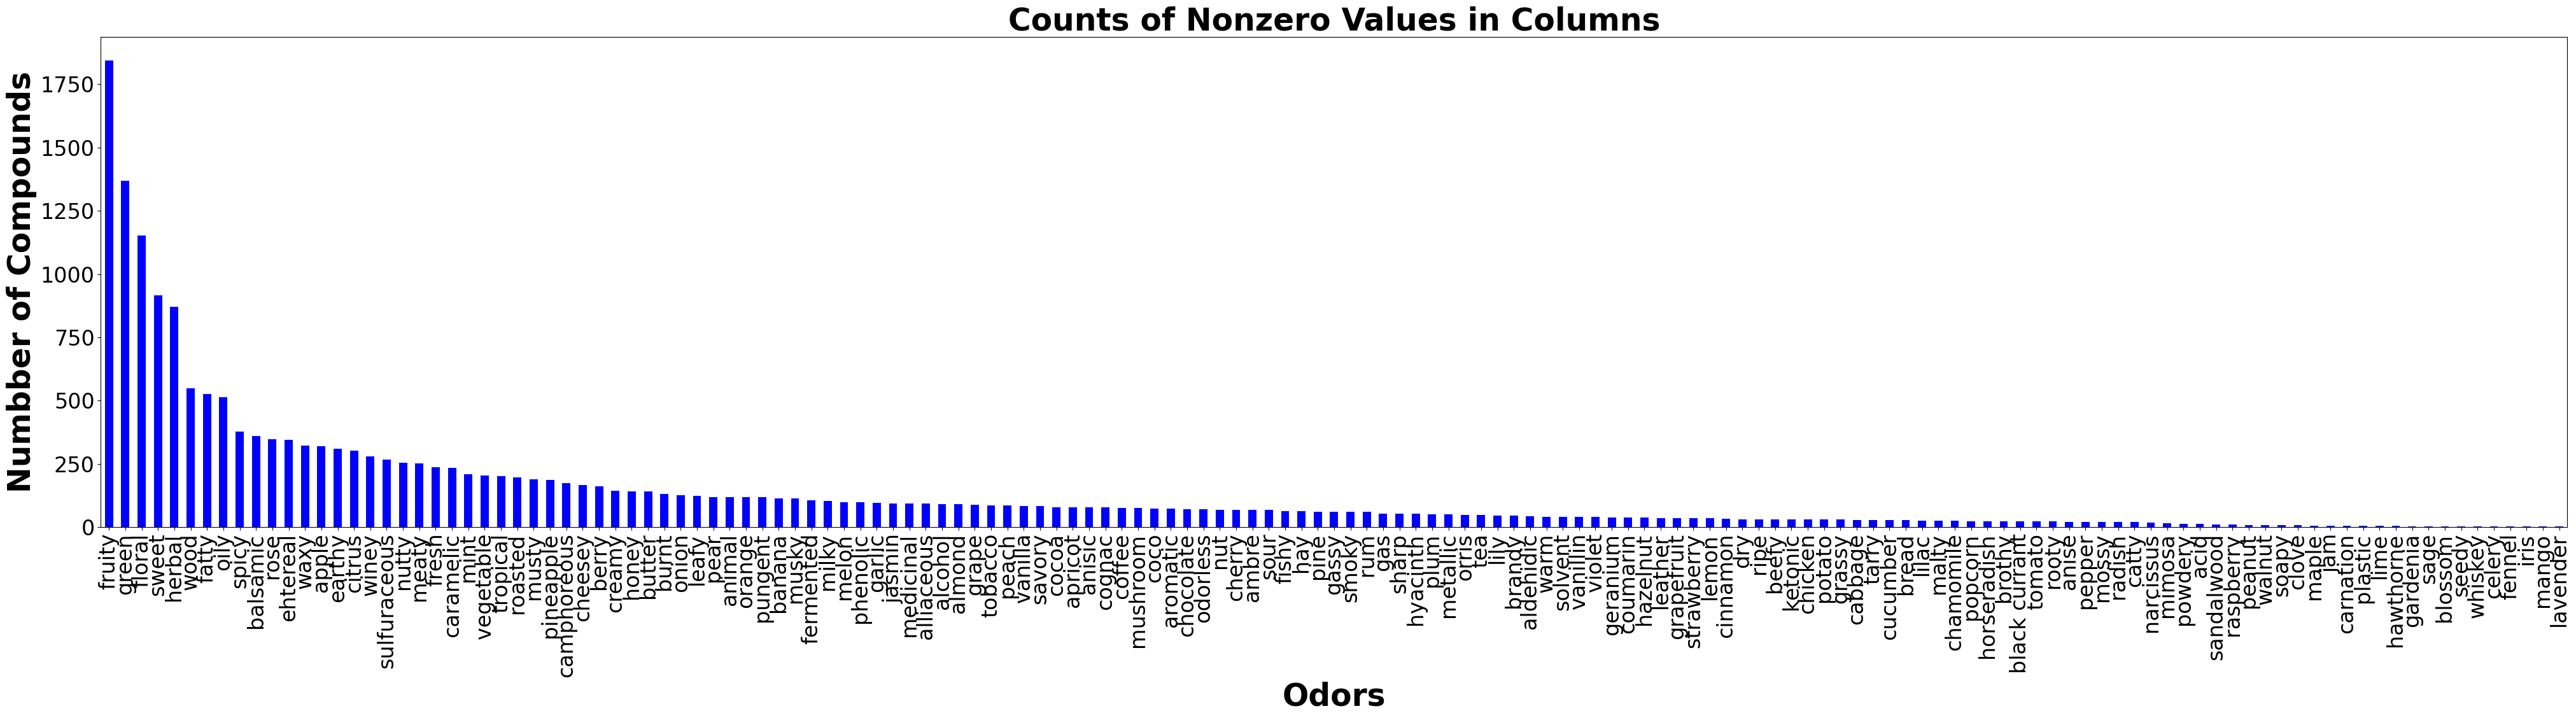

In [ ]:
nonzero_counts = label_a.apply(lambda col: (col != 0).sum())
nonzero=nonzero_counts.to_frame(name ='Count')
new_sort=nonzero.sort_values(by=['Count'],ascending=False)

new_sort.plot(kind='bar', color='blue',figsize=(50, 10),legend=None)

plt.xlabel('Odors',rotation=0,fontsize=35 ,weight='bold')
plt.ylabel('Numbber of Compounds',fontsize=35,weight='bold')
plt.title('Counts of Nonzero Values in Columns',fontsize=35, weight='bold')
plt.xticks(rotation='vertical',fontsize=24)
plt.yticks(fontsize=24)
plt.show()

Features

In [ ]:
## features
Feature_1901=pd.read_csv('/content/drive/MyDrive/pgml/Data analysis/common/update17jan/feature_1901.csv')
Feature_19012 = Feature_1901.iloc[: , 1:]
feature_all=Feature_19012 # features file name
CID=Feature_1901[['CommonCID']]
#feature_all = feature_all[feature_all.isnull().sum(axis=1) < 1000]
feature_all

<ipython-input-10-7ce2fa1767ae>:2: DtypeWarning: Columns (2085,2086,2087,2088,2089,2090,2091,2092,2093,2094,2095,2096,2156,2157,2158,2159,2160,2165,2166,2167,2168,2169,2174,2175,2176,2177,2178,2183,2184,2185,2186,2187,2192,2193,2194,2195,2196,2201,2202,2203,2204,2205,2264,2265,2266,2267,2268,2273,2274,2275,2276,2277,2282,2283,2284,2285,2286,2291,2292,2293,2294,2295,2300,2301,2302,2303,2304,2309,2310,2311,2312,2313,2317,2318,2319,2320,2321,2325,2326,2327,2328,2329,2333,2334,2335,2336,2337,2341,2342,2343,2344,2345,2349,2350,2351,2352,2353,2357,2358,2359,2360,2361,2365,2366,2367,2368,2369,2373,2374,2375,2376,2377,2381,2382,2383,2384,2385,2389,2390,2391,2392,2393,2397,2398,2399,2400,2401,2405,2406,2407,2408,2409,2413,2414,2415,2416,2417,2418,2419,2420,2421,2422,2423,2424,2425,2426,2427,2428,2429,2430,2431,2432,2433,2434,2435,2436,2437,2438,2439,2440,2441,2442,2443,2444,2445,2446,2447,2448,2449,2450,2451,2452,2453,2454,2455,2456,2457,2458,2459,2460,2461,2462,2463,2464,2465,2466,2467,2468,24

,MaxEStateIndex,MinEStateIndex,MaxAbsEStateIndex,MinAbsEStateIndex,qed,MolWt,HeavyAtomMolWt,ExactMolWt,NumValenceElectrons,NumRadicalElectrons,...,TSRW10,WPath,WPol,Zagreb1,Zagreb2,mZagreb1,mZagreb2,PERSISTENCE_ENTROPY_DIM_0,PERSISTENCE_ENTROPY_DIM_1,PERSISTENCE_ENTROPY_DIM_2
0,13.723676,-5.416264,13.723676,2.287573,0.760294,302.458,272.218,302.224580,122.0,0.0,...,57.302060,943.0,45.0,124.0,154.0,8.791666666666666,4.638889,3.947052,2.529469,0.485423
1,9.745935,-5.695194,9.745935,2.728143,0.693521,290.491,256.219,290.260966,120.0,0.0,...,56.028098,834.0,42.0,118.0,146.0,7.930555555555555,4.513889,3.424074,1.140838,0.000000
2,7.945269,-4.130607,7.945269,0.916573,0.509873,210.273,192.129,210.125594,84.0,0.0,...,45.147991,458.0,15.0,64.0,67.0,4.972222222222222,3.666667,3.067019,1.568200,0.000000
3,7.560417,-3.862917,7.560417,3.648895,0.495006,130.187,116.075,130.099380,54.0,0.0,...,36.195345,88.0,10.0,38.0,39.0,2.861111111111111,2.166667,3.141797,1.336667,0.000000
4,7.295906,-4.212500,7.295906,3.689676,0.542862,132.203,116.075,132.115030,56.0,0.0,...,36.755147,96.0,8.0,36.0,36.0,5.0625,2.250000,1.585853,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5208,11.316319,-3.852546,11.316319,0.865463,0.536977,117.148,106.060,117.078979,48.0,0.0,...,35.071670,65.0,8.0,32.0,33.0,5.333333,1.888889,2.853617,1.355357,0.000000
5209,12.358586,-3.629951,12.358586,1.086318,0.731363,222.240,208.128,222.089209,86.0,0.0,...,47.511782,446.0,22.0,72.0,81.0,6.444444,3.916667,3.345647,1.552718,0.000000
5210,12.690049,-3.735398,12.690049,0.325212,0.661030,241.290,226.170,241.110279,92.0,0.0,...,50.261825,702.0,23.0,86.0,96.0,5.444444,4.138889,3.435885,1.277218,0.000000
5211,7.192708,-3.078125,7.192708,0.291667,0.434794,71.123,62.051,71.073499,30.0,0.0,...,41.004802,15.0,0.0,20.0,20.0,1.25,1.250000,2.553369,0.244144,0.000000


# Features selections

## Step 1 Remove NAN values

Check how many Nan values in the features data

In [ ]:
print(feature_all.isna().sum().sum())
print(feature_all.isnull().values.any())
def isnumber(x):
    try:
        float(x)
        return True
    except:
        return False

feature_all=feature_all[feature_all.applymap(isnumber)]
feature_all

626481
True


<ipython-input-11-2e8003c55453>:10: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  feature_all=feature_all[feature_all.applymap(isnumber)]


,MaxEStateIndex,MinEStateIndex,MaxAbsEStateIndex,MinAbsEStateIndex,qed,MolWt,HeavyAtomMolWt,ExactMolWt,NumValenceElectrons,NumRadicalElectrons,...,TSRW10,WPath,WPol,Zagreb1,Zagreb2,mZagreb1,mZagreb2,PERSISTENCE_ENTROPY_DIM_0,PERSISTENCE_ENTROPY_DIM_1,PERSISTENCE_ENTROPY_DIM_2
0,13.723676,-5.416264,13.723676,2.287573,0.760294,302.458,272.218,302.224580,122.0,0.0,...,57.302060,943.0,45.0,124.0,154.0,8.791666666666666,4.638889,3.947052,2.529469,0.485423
1,9.745935,-5.695194,9.745935,2.728143,0.693521,290.491,256.219,290.260966,120.0,0.0,...,56.028098,834.0,42.0,118.0,146.0,7.930555555555555,4.513889,3.424074,1.140838,0.000000
2,7.945269,-4.130607,7.945269,0.916573,0.509873,210.273,192.129,210.125594,84.0,0.0,...,45.147991,458.0,15.0,64.0,67.0,4.972222222222222,3.666667,3.067019,1.568200,0.000000
3,7.560417,-3.862917,7.560417,3.648895,0.495006,130.187,116.075,130.099380,54.0,0.0,...,36.195345,88.0,10.0,38.0,39.0,2.861111111111111,2.166667,3.141797,1.336667,0.000000
4,7.295906,-4.212500,7.295906,3.689676,0.542862,132.203,116.075,132.115030,56.0,0.0,...,36.755147,96.0,8.0,36.0,36.0,5.0625,2.250000,1.585853,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5208,11.316319,-3.852546,11.316319,0.865463,0.536977,117.148,106.060,117.078979,48.0,0.0,...,35.071670,65.0,8.0,32.0,33.0,5.333333,1.888889,2.853617,1.355357,0.000000
5209,12.358586,-3.629951,12.358586,1.086318,0.731363,222.240,208.128,222.089209,86.0,0.0,...,47.511782,446.0,22.0,72.0,81.0,6.444444,3.916667,3.345647,1.552718,0.000000
5210,12.690049,-3.735398,12.690049,0.325212,0.661030,241.290,226.170,241.110279,92.0,0.0,...,50.261825,702.0,23.0,86.0,96.0,5.444444,4.138889,3.435885,1.277218,0.000000
5211,7.192708,-3.078125,7.192708,0.291667,0.434794,71.123,62.051,71.073499,30.0,0.0,...,41.004802,15.0,0.0,20.0,20.0,1.25,1.250000,2.553369,0.244144,0.000000


Data have infinite values, replace infinite to nan values

In [ ]:
X_a = feature_all.apply(pd.to_numeric, errors='coerce')
X_a.replace([np.inf, -np.inf], np.nan, inplace=True)
count = np.isinf(X_a).values.sum()
print("It contains " + str(count) + " infinite values")

It contains 0 infinite values


Drop all columns with nan

In [ ]:
## drop all columns with nan
X_a.dropna(axis=1, inplace=True)
X_a

,MaxEStateIndex,MinEStateIndex,MaxAbsEStateIndex,MinAbsEStateIndex,qed,MolWt,HeavyAtomMolWt,ExactMolWt,NumValenceElectrons,NumRadicalElectrons,...,SRW09,TSRW10,WPath,WPol,Zagreb1,Zagreb2,mZagreb2,PERSISTENCE_ENTROPY_DIM_0,PERSISTENCE_ENTROPY_DIM_1,PERSISTENCE_ENTROPY_DIM_2
0,13.723676,-5.416264,13.723676,2.287573,0.760294,302.458,272.218,302.224580,122.0,0.0,...,0.000000,57.302060,943.0,45.0,124.0,154.0,4.638889,3.947052,2.529469,0.485423
1,9.745935,-5.695194,9.745935,2.728143,0.693521,290.491,256.219,290.260966,120.0,0.0,...,0.000000,56.028098,834.0,42.0,118.0,146.0,4.513889,3.424074,1.140838,0.000000
2,7.945269,-4.130607,7.945269,0.916573,0.509873,210.273,192.129,210.125594,84.0,0.0,...,0.000000,45.147991,458.0,15.0,64.0,67.0,3.666667,3.067019,1.568200,0.000000
3,7.560417,-3.862917,7.560417,3.648895,0.495006,130.187,116.075,130.099380,54.0,0.0,...,0.000000,36.195345,88.0,10.0,38.0,39.0,2.166667,3.141797,1.336667,0.000000
4,7.295906,-4.212500,7.295906,3.689676,0.542862,132.203,116.075,132.115030,56.0,0.0,...,0.000000,36.755147,96.0,8.0,36.0,36.0,2.250000,1.585853,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5208,11.316319,-3.852546,11.316319,0.865463,0.536977,117.148,106.060,117.078979,48.0,0.0,...,0.000000,35.071670,65.0,8.0,32.0,33.0,1.888889,2.853617,1.355357,0.000000
5209,12.358586,-3.629951,12.358586,1.086318,0.731363,222.240,208.128,222.089209,86.0,0.0,...,0.000000,47.511782,446.0,22.0,72.0,81.0,3.916667,3.345647,1.552718,0.000000
5210,12.690049,-3.735398,12.690049,0.325212,0.661030,241.290,226.170,241.110279,92.0,0.0,...,0.000000,50.261825,702.0,23.0,86.0,96.0,4.138889,3.435885,1.277218,0.000000
5211,7.192708,-3.078125,7.192708,0.291667,0.434794,71.123,62.051,71.073499,30.0,0.0,...,5.888878,41.004802,15.0,0.0,20.0,20.0,1.250000,2.553369,0.244144,0.000000


In [ ]:
# Save the DataFrame to a CSV file
df_selected_columns = pd.DataFrame(X_a.columns)
df_selected_columns.to_csv('nan_columns.csv', index=False)

# Split data

In [ ]:
## split data for multi label data

from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit
msss = MultilabelStratifiedShuffleSplit(n_splits=10, test_size=0.25, random_state=0)

for train_index, test_index in msss.split(X_a, y):
   #print("TRAIN:", train_index, "TEST:", test_index)
   X_train, X_test = X_a.loc[train_index], X_a.loc[test_index]
   y_train, y_test = y.loc[train_index], y.loc[test_index]

In this step to make sure every test dataset have one smell label.

In [ ]:
nonzero_counts = y.apply(lambda col: (col != 0).sum())
y_train_a = y_train.loc[:, nonzero_counts >= 2]
y_test_a = y_test.loc[:, nonzero_counts >= 2]

Save the splitted data

In [ ]:
y_train_a.to_csv('y_train.csv', index=False)
y_test_a.to_csv('y_test.csv', index=False)
X_train.to_csv('X_train.csv', index=False)
X_test.to_csv('X_test.csv', index=False)

https://stats.stackexchange.com/questions/546421/do-i-split-before-or-after-cleaning-code

https://stats.stackexchange.com/questions/521188/avoiding-data-leakage-in-preprocessing

https://medium.com/aiskunks/imputation-techniques-for-numerical-features-1331d427fff1#:~:text=In%20conclusion%2C%20data%20imputation%20for,deck%20imputation%20as%20shown%20above.
https://jamesrledoux.com/code/imputation

https://stats.stackexchange.com/questions/214728/should-data-be-normalized-before-or-after-imputation-of-missing-data

### Step 2 variance

Features without much variance or variability in the data do not provide any information to an ML model for learning the patterns. For example, a feature with only 5 as a value for every record in a dataset is a constant and is an unimportant feature to be used

In [ ]:
selector = VarianceThreshold(threshold=0.00)
X_train4_selected = selector.fit_transform(X_train)
remaining_indices = selector.get_support(indices=True)
X_train4_cols = X_train.columns[remaining_indices]
scaled_features_df = pd.DataFrame(X_train4_selected, columns=X_train4_cols)
scaled_features_df

/usr/local/lib/python3.10/dist-packages/numpy/core/fromnumeric.py:88: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


,MaxEStateIndex,MinEStateIndex,MaxAbsEStateIndex,MinAbsEStateIndex,qed,MolWt,HeavyAtomMolWt,ExactMolWt,NumValenceElectrons,MaxPartialCharge,...,SRW09,TSRW10,WPath,WPol,Zagreb1,Zagreb2,mZagreb2,PERSISTENCE_ENTROPY_DIM_0,PERSISTENCE_ENTROPY_DIM_1,PERSISTENCE_ENTROPY_DIM_2
0,13.723676,-5.416264,13.723676,2.287573,0.760294,302.458,272.218,302.224580,122.0,0.309162,...,0.000000,57.302060,943.0,45.0,124.0,154.0,4.638889,3.947052,2.529469,0.485423
1,9.745935,-5.695194,9.745935,2.728143,0.693521,290.491,256.219,290.260966,120.0,0.210065,...,0.000000,56.028098,834.0,42.0,118.0,146.0,4.513889,3.424074,1.140838,0.000000
2,7.945269,-4.130607,7.945269,0.916573,0.509873,210.273,192.129,210.125594,84.0,0.154861,...,0.000000,45.147991,458.0,15.0,64.0,67.0,3.666667,3.067019,1.568200,0.000000
3,7.560417,-3.862917,7.560417,3.648895,0.495006,130.187,116.075,130.099380,54.0,0.154284,...,0.000000,36.195345,88.0,10.0,38.0,39.0,2.166667,3.141797,1.336667,0.000000
4,7.295906,-4.212500,7.295906,3.689676,0.542862,132.203,116.075,132.115030,56.0,0.162201,...,0.000000,36.755147,96.0,8.0,36.0,36.0,2.250000,1.585853,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3904,12.205543,-4.086157,12.205543,1.820912,0.354766,196.290,176.130,196.146330,80.0,0.309136,...,0.000000,42.328392,420.0,12.0,52.0,51.0,3.666667,3.463763,0.168566,0.000000
3905,11.349456,-3.464213,11.349456,1.093097,0.385005,176.124,168.060,176.032088,68.0,0.377497,...,6.985642,56.914288,188.0,17.0,58.0,68.0,2.777778,2.910674,0.649751,0.000000
3906,12.358586,-3.629951,12.358586,1.086318,0.731363,222.240,208.128,222.089209,86.0,0.338496,...,0.000000,47.511782,446.0,22.0,72.0,81.0,3.916667,3.345647,1.552718,0.000000
3907,7.192708,-3.078125,7.192708,0.291667,0.434794,71.123,62.051,71.073499,30.0,0.122190,...,5.888878,41.004802,15.0,0.0,20.0,20.0,1.250000,2.553369,0.244144,0.000000


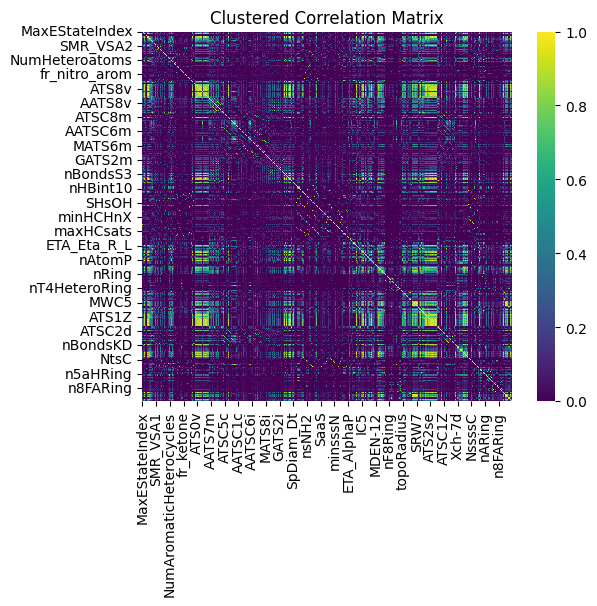

In [ ]:
corr_matrix = scaled_features_df.corr()
sns.heatmap(corr_matrix, annot=False, cmap='viridis', vmin=0, vmax=1,square=True)
n = 50  # Show every 10th label
plt.xticks(range(0, corr_matrix.shape[1], n), corr_matrix.columns[::n], rotation=90)
plt.title('Clustered Correlation Matrix')
plt.savefig('a.png',dpi=100)
plt.show()

Save the feature selector

In [ ]:
import joblib
joblib.dump(selector, 'selector.pkl')

['selector.pkl']

In [ ]:
f_test_selected = selector.transform(X_test)
remaining_indices = selector.get_support(indices=True)
f_test_cols = X_test.columns[remaining_indices]

f_testb=pd.DataFrame(f_test_selected, columns=f_test_cols)

# Optionally, get the column names of the remaining features
f_testa=X_test[f_test_cols]
f_testa


,MaxEStateIndex,MinEStateIndex,MaxAbsEStateIndex,MinAbsEStateIndex,qed,MolWt,HeavyAtomMolWt,ExactMolWt,NumValenceElectrons,MaxPartialCharge,...,SRW09,TSRW10,WPath,WPol,Zagreb1,Zagreb2,mZagreb2,PERSISTENCE_ENTROPY_DIM_0,PERSISTENCE_ENTROPY_DIM_1,PERSISTENCE_ENTROPY_DIM_2
7,11.886276,-3.314717,11.886276,0.405664,0.718509,185.226,174.138,185.084064,70.0,0.135273,...,0.000000,45.493017,308.0,18.0,70.0,79.0,3.111111,2.606195,0.000000,0.0
12,13.053132,-4.762303,13.053132,1.759236,0.669024,244.378,220.186,244.182715,98.0,0.159576,...,7.515889,67.359883,519.0,36.0,102.0,127.0,3.666667,3.750266,2.446910,0.0
16,11.985928,-3.353377,11.985928,0.931474,0.579148,194.186,184.106,194.057909,74.0,0.293294,...,0.000000,45.239446,303.0,20.0,66.0,75.0,3.250000,3.428716,0.924027,0.0
19,10.058148,-1.282407,10.058148,0.912037,0.450858,72.063,68.031,72.021129,28.0,0.327198,...,0.000000,27.254130,18.0,2.0,16.0,14.0,1.333333,3.098960,0.000000,0.0
26,13.886744,-5.541624,13.886744,2.481545,0.580634,300.486,268.230,300.245316,122.0,0.132960,...,7.065613,71.900278,917.0,46.0,130.0,165.0,4.583333,3.054224,0.400528,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5185,7.663483,-3.676415,7.663483,1.569873,0.458571,140.226,124.098,140.120115,58.0,0.210499,...,0.000000,35.643477,165.0,7.0,34.0,32.0,2.750000,3.164504,0.000000,0.0
5190,11.843994,-3.977809,11.843994,1.775811,0.385650,172.224,156.096,172.109944,70.0,0.334169,...,0.000000,40.156271,256.0,11.0,46.0,46.0,3.027778,3.261954,0.000000,0.0
5194,7.735821,-4.233615,7.735821,1.702252,0.446018,142.242,124.098,142.135765,60.0,0.210499,...,0.000000,35.643477,165.0,7.0,34.0,32.0,2.750000,3.208285,0.000000,0.0
5208,11.316319,-3.852546,11.316319,0.865463,0.536977,117.148,106.060,117.078979,48.0,0.320236,...,0.000000,35.071670,65.0,8.0,32.0,33.0,1.888889,2.853617,1.355357,0.0


### Step 3 Remove high corr

https://feature-engine.trainindata.com/en/latest/user_guide/selection/DropCorrelatedFeatures.html#

In [ ]:
dcor_tr = DropCorrelatedFeatures(
    variables=None,method='pearson' , threshold=0.9
)
X_dcor = dcor_tr.fit_transform(scaled_features_df)

X_dcor

,MinEStateIndex,MaxAbsEStateIndex,MinAbsEStateIndex,qed,MaxPartialCharge,MaxAbsPartialCharge,FpDensityMorgan1,FpDensityMorgan3,BalabanJ,Chi2v,...,n12FAHRing,nG12FAHRing,Diameter,MWC02,SRW03,SRW05,TSRW10,PERSISTENCE_ENTROPY_DIM_0,PERSISTENCE_ENTROPY_DIM_1,PERSISTENCE_ENTROPY_DIM_2
0,-5.416264,13.723676,2.287573,0.760294,0.309162,0.480821,1.636364,3.272727,3.157731,4.662457,...,0.0,0.0,10.0,4.828314,0.0,0.000000,57.302060,3.947052,2.529469,0.485423
1,-5.695194,9.745935,2.728143,0.693521,0.210065,0.395798,1.571429,3.285714,3.224658,4.477062,...,0.0,0.0,10.0,4.779123,0.0,0.000000,56.028098,3.424074,1.140838,0.000000
2,-4.130607,7.945269,0.916573,0.509873,0.154861,0.382296,1.400000,3.000000,3.585884,1.899830,...,0.0,0.0,11.0,4.174387,0.0,0.000000,45.147991,3.067019,1.568200,0.000000
3,-3.862917,7.560417,3.648895,0.495006,0.154284,0.352975,1.444444,2.666667,3.721251,1.070706,...,0.0,0.0,5.0,3.663562,0.0,0.000000,36.195345,3.141797,1.336667,0.000000
4,-4.212500,7.295906,3.689676,0.542862,0.162201,0.350820,1.333333,2.222222,6.520178,1.024830,...,0.0,0.0,6.0,3.610918,0.0,0.000000,36.755147,1.585853,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3904,-4.086157,12.205543,1.820912,0.354766,0.309136,0.465117,1.357143,2.785714,6.393765,1.491582,...,0.0,0.0,12.0,3.970292,0.0,0.000000,42.328392,3.463763,0.168566,0.000000
3905,-3.464213,11.349456,1.093097,0.385005,0.377497,0.505047,1.916667,3.416667,3.488536,1.808078,...,0.0,0.0,6.0,4.077537,0.0,2.397895,56.914288,2.910674,0.649751,0.000000
3906,-3.629951,12.358586,1.086318,0.731363,0.338496,0.462372,1.187500,2.000000,3.655531,2.233163,...,0.0,0.0,9.0,4.290459,0.0,0.000000,47.511782,3.345647,1.552718,0.000000
3907,-3.078125,7.192708,0.291667,0.434794,0.122190,0.316731,1.600000,2.400000,3.384671,0.585410,...,0.0,0.0,2.0,3.044522,0.0,2.397895,41.004802,2.553369,0.244144,0.000000


Save the feature selector

In [ ]:
joblib.dump(dcor_tr, 'dcor_tr.pkl')

['dcor_tr.pkl']

In [ ]:
drop_cols=dcor_tr.features_to_drop_
f_testa.drop(drop_cols, axis=1, inplace=True)
f_testa

<ipython-input-23-b590633adefb>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  f_testa.drop(drop_cols, axis=1, inplace=True)


,MinEStateIndex,MaxAbsEStateIndex,MinAbsEStateIndex,qed,MaxPartialCharge,MaxAbsPartialCharge,FpDensityMorgan1,FpDensityMorgan3,BalabanJ,Chi2v,...,n12FAHRing,nG12FAHRing,Diameter,MWC02,SRW03,SRW05,TSRW10,PERSISTENCE_ENTROPY_DIM_0,PERSISTENCE_ENTROPY_DIM_1,PERSISTENCE_ENTROPY_DIM_2
7,-3.314717,11.886276,0.405664,0.718509,0.135273,0.299592,1.500000,3.214286,2.943085,2.388141,...,0.0,0.0,8.0,4.262680,0.0,0.000000,45.493017,2.606195,0.000000,0.0
12,-4.762303,13.053132,1.759236,0.669024,0.159576,0.294501,1.277778,2.444444,3.889911,3.954124,...,0.0,0.0,7.0,4.634729,0.0,2.397895,67.359883,3.750266,2.446910,0.0
16,-3.353377,11.985928,0.931474,0.579148,0.293294,0.504254,1.642857,3.142857,3.693644,2.168559,...,0.0,0.0,7.0,4.204693,0.0,0.000000,45.239446,3.428716,0.924027,0.0
19,-1.282407,10.058148,0.912037,0.450858,0.327198,0.478089,2.800000,3.800000,4.206977,0.412457,...,0.0,0.0,3.0,2.833213,0.0,0.000000,27.254130,3.098960,0.000000,0.0
26,-5.541624,13.886744,2.481545,0.580634,0.132960,0.299694,1.318182,3.090909,2.687749,4.954124,...,0.0,0.0,10.0,4.875197,0.0,2.397895,71.900278,3.054224,0.400528,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5185,-3.676415,7.663483,1.569873,0.458571,0.210499,0.392308,1.500000,3.000000,6.480434,0.977062,...,0.0,0.0,9.0,3.555348,0.0,0.000000,35.643477,3.164504,0.000000,0.0
5190,-3.977809,11.843994,1.775811,0.385650,0.334169,0.463454,2.083333,3.666667,6.152621,1.320706,...,0.0,0.0,9.0,3.850148,0.0,0.000000,40.156271,3.261954,0.000000,0.0
5194,-4.233615,7.735821,1.702252,0.446018,0.210499,0.392308,1.600000,3.400000,6.685085,0.977062,...,0.0,0.0,9.0,3.555348,0.0,0.000000,35.643477,3.208285,0.000000,0.0
5208,-3.852546,11.316319,0.865463,0.536977,0.320236,0.480079,2.250000,3.375000,6.347027,1.011064,...,0.0,0.0,4.0,3.496508,0.0,0.000000,35.071670,2.853617,1.355357,0.0


In [ ]:
scaled_features_df.to_csv('/content/clean_train_feature_2702.csv',index=False)

 Remove  correlation coefficient with nan values

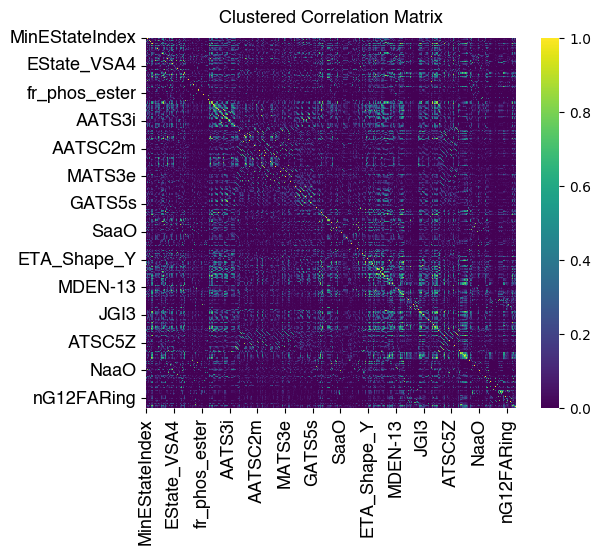

In [ ]:
#corr_matrix = scaled_features_df.corr()


X_dcor.drop(['ETA_AlphaP','gmin'], axis=1, inplace=True)

myfont = FontProperties(fname=r'/usr/local/lib/python3.10/dist-packages/matplotlib/mpl-data/fonts/ttf/Helvetica.ttf',size=13)
corr_matrix = X_dcor.corr()

sns.heatmap(corr_matrix, annot=False, cmap='viridis', vmin=0, vmax=1,square=True)
n = 50  # Show every 10th label
plt.xticks(range(0, corr_matrix.shape[1], n), corr_matrix.columns[::n], rotation=90,fontproperties=myfont)
plt.yticks(range(0, corr_matrix.shape[1], n), corr_matrix.columns[::n], rotation=0,fontproperties=myfont)
plt.title('Clustered Correlation Matrix',fontproperties=myfont,y=1.02)
plt.savefig('a.png',dpi=100)
plt.show()

In [ ]:
corr_matrix.to_csv('/content/corr_matrix.csv',index=False)

## Step 4 Feature improtant

In [ ]:
# step4  train

#https://vitalflux.com/feature-importance-random-forest-classifier-python/
from sklearn.ensemble import RandomForestClassifier
# Create training and test split
from sklearn.preprocessing import MinMaxScaler
#scaler=StandardScaler()
scaler=MinMaxScaler()
X_train_b = scaler.fit_transform(X_dcor)
forest = RandomForestClassifier(n_estimators=100,random_state=42)
forest.fit(X_train_b, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
# get the feature importances

feature_names=X_dcor.columns
importances = forest.feature_importances_
sorted_indices = np.argsort(importances)[::-1]
# print the feature importances
for i, importance in enumerate(importances):
    print(f'{feature_names[i]}: {importance:.3f}')

MinEStateIndex: 0.003
MaxAbsEStateIndex: 0.003
MinAbsEStateIndex: 0.003
qed: 0.003
MaxPartialCharge: 0.003
MaxAbsPartialCharge: 0.003
FpDensityMorgan1: 0.002
FpDensityMorgan3: 0.003
BalabanJ: 0.004
Chi2v: 0.002
Chi3n: 0.002
HallKierAlpha: 0.002
Ipc: 0.000
Kappa1: 0.002
Kappa2: 0.002
Kappa3: 0.003
PEOE_VSA1: 0.001
PEOE_VSA10: 0.001
PEOE_VSA11: 0.001
PEOE_VSA12: 0.000
PEOE_VSA13: 0.000
PEOE_VSA14: 0.000
PEOE_VSA2: 0.001
PEOE_VSA3: 0.000
PEOE_VSA4: 0.000
PEOE_VSA5: 0.000
PEOE_VSA6: 0.002
PEOE_VSA7: 0.002
PEOE_VSA8: 0.002
PEOE_VSA9: 0.002
SMR_VSA1: 0.002
SMR_VSA10: 0.001
SMR_VSA2: 0.000
SMR_VSA3: 0.000
SMR_VSA4: 0.001
SMR_VSA6: 0.001
SMR_VSA9: 0.000
SlogP_VSA1: 0.000
SlogP_VSA10: 0.000
SlogP_VSA12: 0.001
SlogP_VSA2: 0.002
SlogP_VSA3: 0.001
SlogP_VSA4: 0.001
SlogP_VSA7: 0.000
SlogP_VSA8: 0.000
TPSA: 0.001
EState_VSA10: 0.000
EState_VSA11: 0.000
EState_VSA2: 0.000
EState_VSA3: 0.000
EState_VSA4: 0.000
EState_VSA5: 0.000
EState_VSA6: 0.000
EState_VSA7: 0.000
EState_VSA8: 0.001
VSA_EState10: 0

In [ ]:
# create dataframe with feature names and importances
df_feature_importances = pd.DataFrame({'feature': feature_names, 'importance': importances})

# write dataframe to csv file
#df_feature_importances.to_csv('feature_importances.csv', index=False)
# sort dataframe by importance in descending order
df_feature_importances = df_feature_importances.sort_values(by='importance', ascending=False)

# write dataframe to csv file
df_feature_importances.to_csv('feature_importances.csv', index=False)
df_feature_importances

,feature,importance
664,PERSISTENCE_ENTROPY_DIM_0,0.019900
665,PERSISTENCE_ENTROPY_DIM_1,0.011459
8,BalabanJ,0.003636
299,GATS4s,0.003617
296,GATS1s,0.003538
...,...,...
626,n11ARing,0.000000
100,fr_phos_ester,0.000000
634,n11AHRing,0.000000
98,fr_oxime,0.000000


Using matplotlib backend: <object object at 0x786b8958f6c0>
Populating the interactive namespace from numpy and matplotlib


/usr/local/lib/python3.10/dist-packages/IPython/core/magics/pylab.py:159: UserWarning: pylab import has clobbered these variables: ['nonzero']
`%matplotlib` prevents importing * from pylab and numpy
  warn("pylab import has clobbered these variables: %s"  % clobbered +


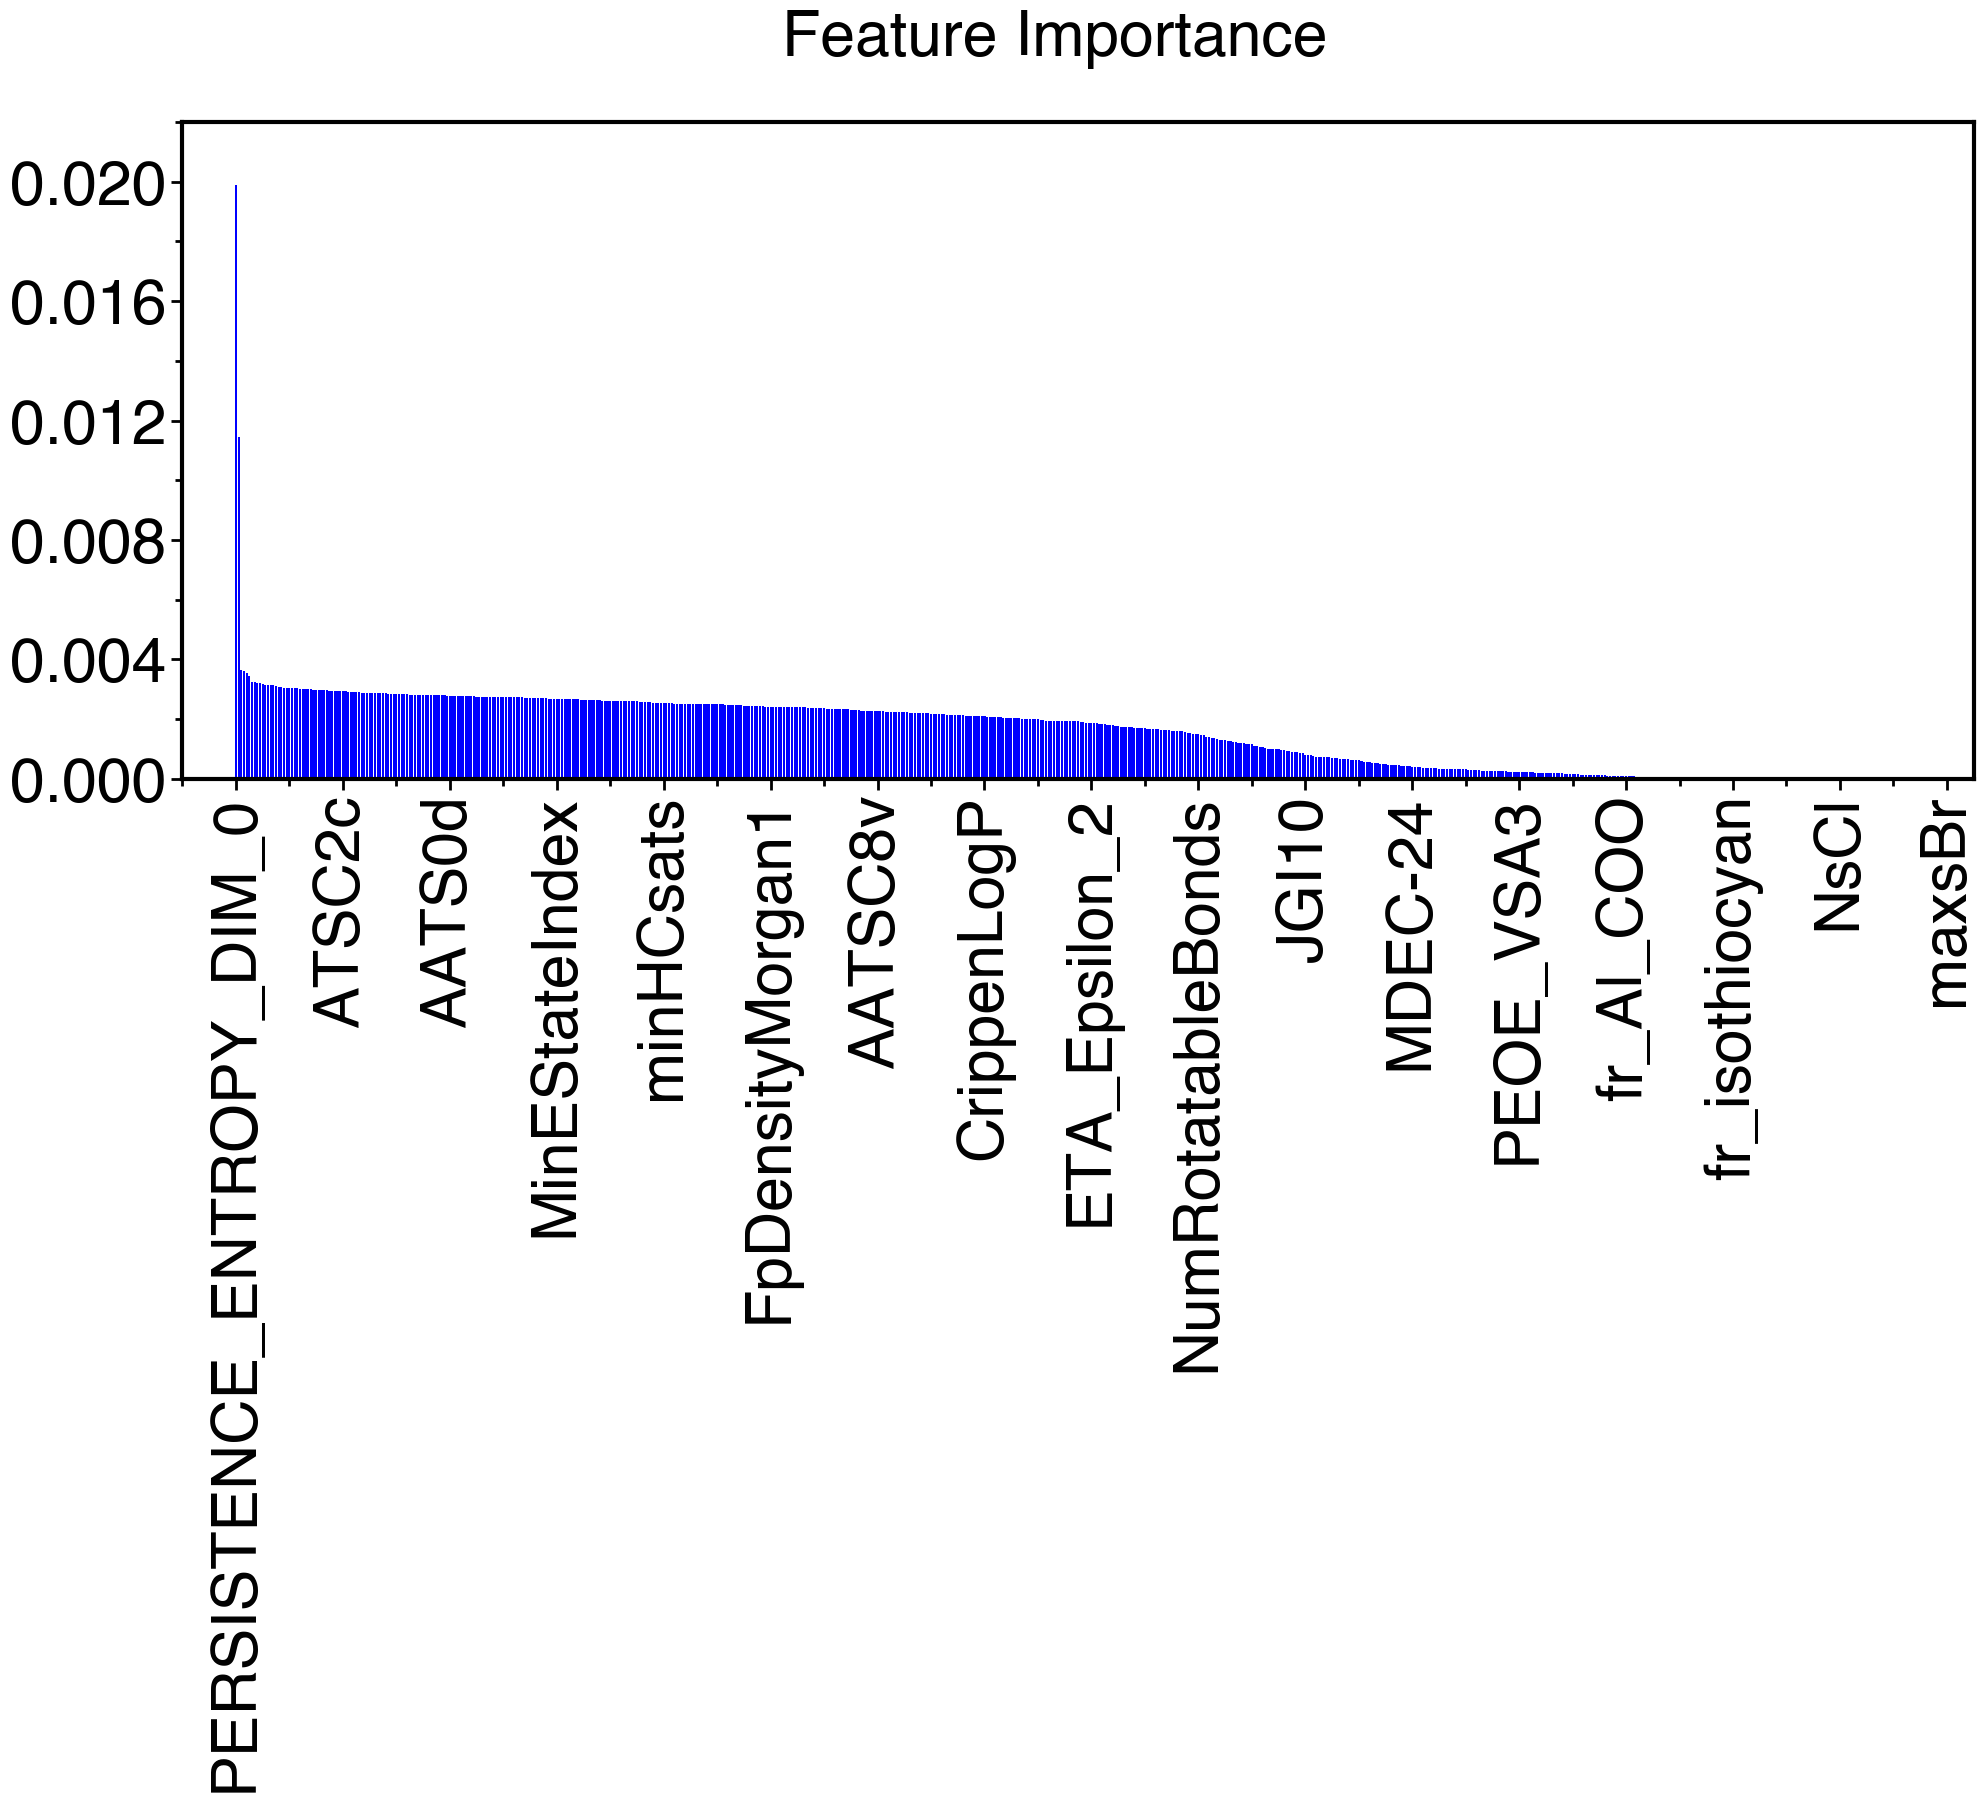

In [ ]:

%matplotlib
%pylab inline
c = '#7eb54e'
## change change fname=r'/Helvetica-Font/Helvetica.ttf'
myfont = FontProperties(fname=r'/usr/local/lib/python3.10/dist-packages/matplotlib/mpl-data/fonts/ttf/Helvetica.ttf',size=45)
#plt.bar(range(X_train.shape[1]), importances[sorted_indices], align='center',color =c)
# Create a subplot
fig, ax = plt.subplots(1,1,figsize=(20, 17))

ax.bar(range(X_dcor.shape[1]), importances[sorted_indices], align='center',color ='blue')
#plt.xticks(range(0,1400,10), X.columns[sorted_indices], rotation=90)
n = 20  # Show every 10th label
plt.xticks(range(0, X_dcor.shape[1], n), X_dcor.columns[sorted_indices[::n]], rotation=90)

ax.xaxis.set_major_locator(MultipleLocator(40))
ax.xaxis.set_minor_locator(MultipleLocator(20))
ax.yaxis.set_major_locator(MultipleLocator(0.004))
ax.yaxis.set_minor_locator(MultipleLocator(0.002))
ax.tick_params(axis='y', right=False)
ax.tick_params(which='both', width=2)
ax.tick_params(which='major', length=8)
ax.tick_params(which='minor', length=5)
ax.grid(False)
plt.setp(ax, xlim=(-20,650), ylim=(0,0.022))
plt.setp(ax.get_xticklabels(), fontsize=20,fontproperties=myfont)
plt.setp(ax.get_yticklabels(), fontsize=20,fontproperties=myfont)

# change all spines
# Customize the spines
for spine in ax.spines.values():
    spine.set_linewidth(3)  # Set the linewidth
    spine.set_color('k')  # Set the color
    spine.set_linestyle('-')  # Set the linestyle
#plt.title('Feature Importance',fontproperties=myfont, fontsize=20)
fig.text(0.53, 1.03, 'Feature Importance', ha='center',fontproperties=myfont)
plt.tight_layout()
plt.show()

Drop less improtant features

In [ ]:
# if the value ==0
df_feature_K = df_feature_importances[df_feature_importances.importance >0.0001]
df_feature_K

,feature,importance
664,PERSISTENCE_ENTROPY_DIM_0,0.019900
665,PERSISTENCE_ENTROPY_DIM_1,0.011459
8,BalabanJ,0.003636
299,GATS4s,0.003617
296,GATS1s,0.003538
...,...,...
65,NumAromaticHeterocycles,0.000121
112,nAcid,0.000112
49,EState_VSA3,0.000101
602,NdS,0.000101


Using matplotlib backend: agg
Populating the interactive namespace from numpy and matplotlib


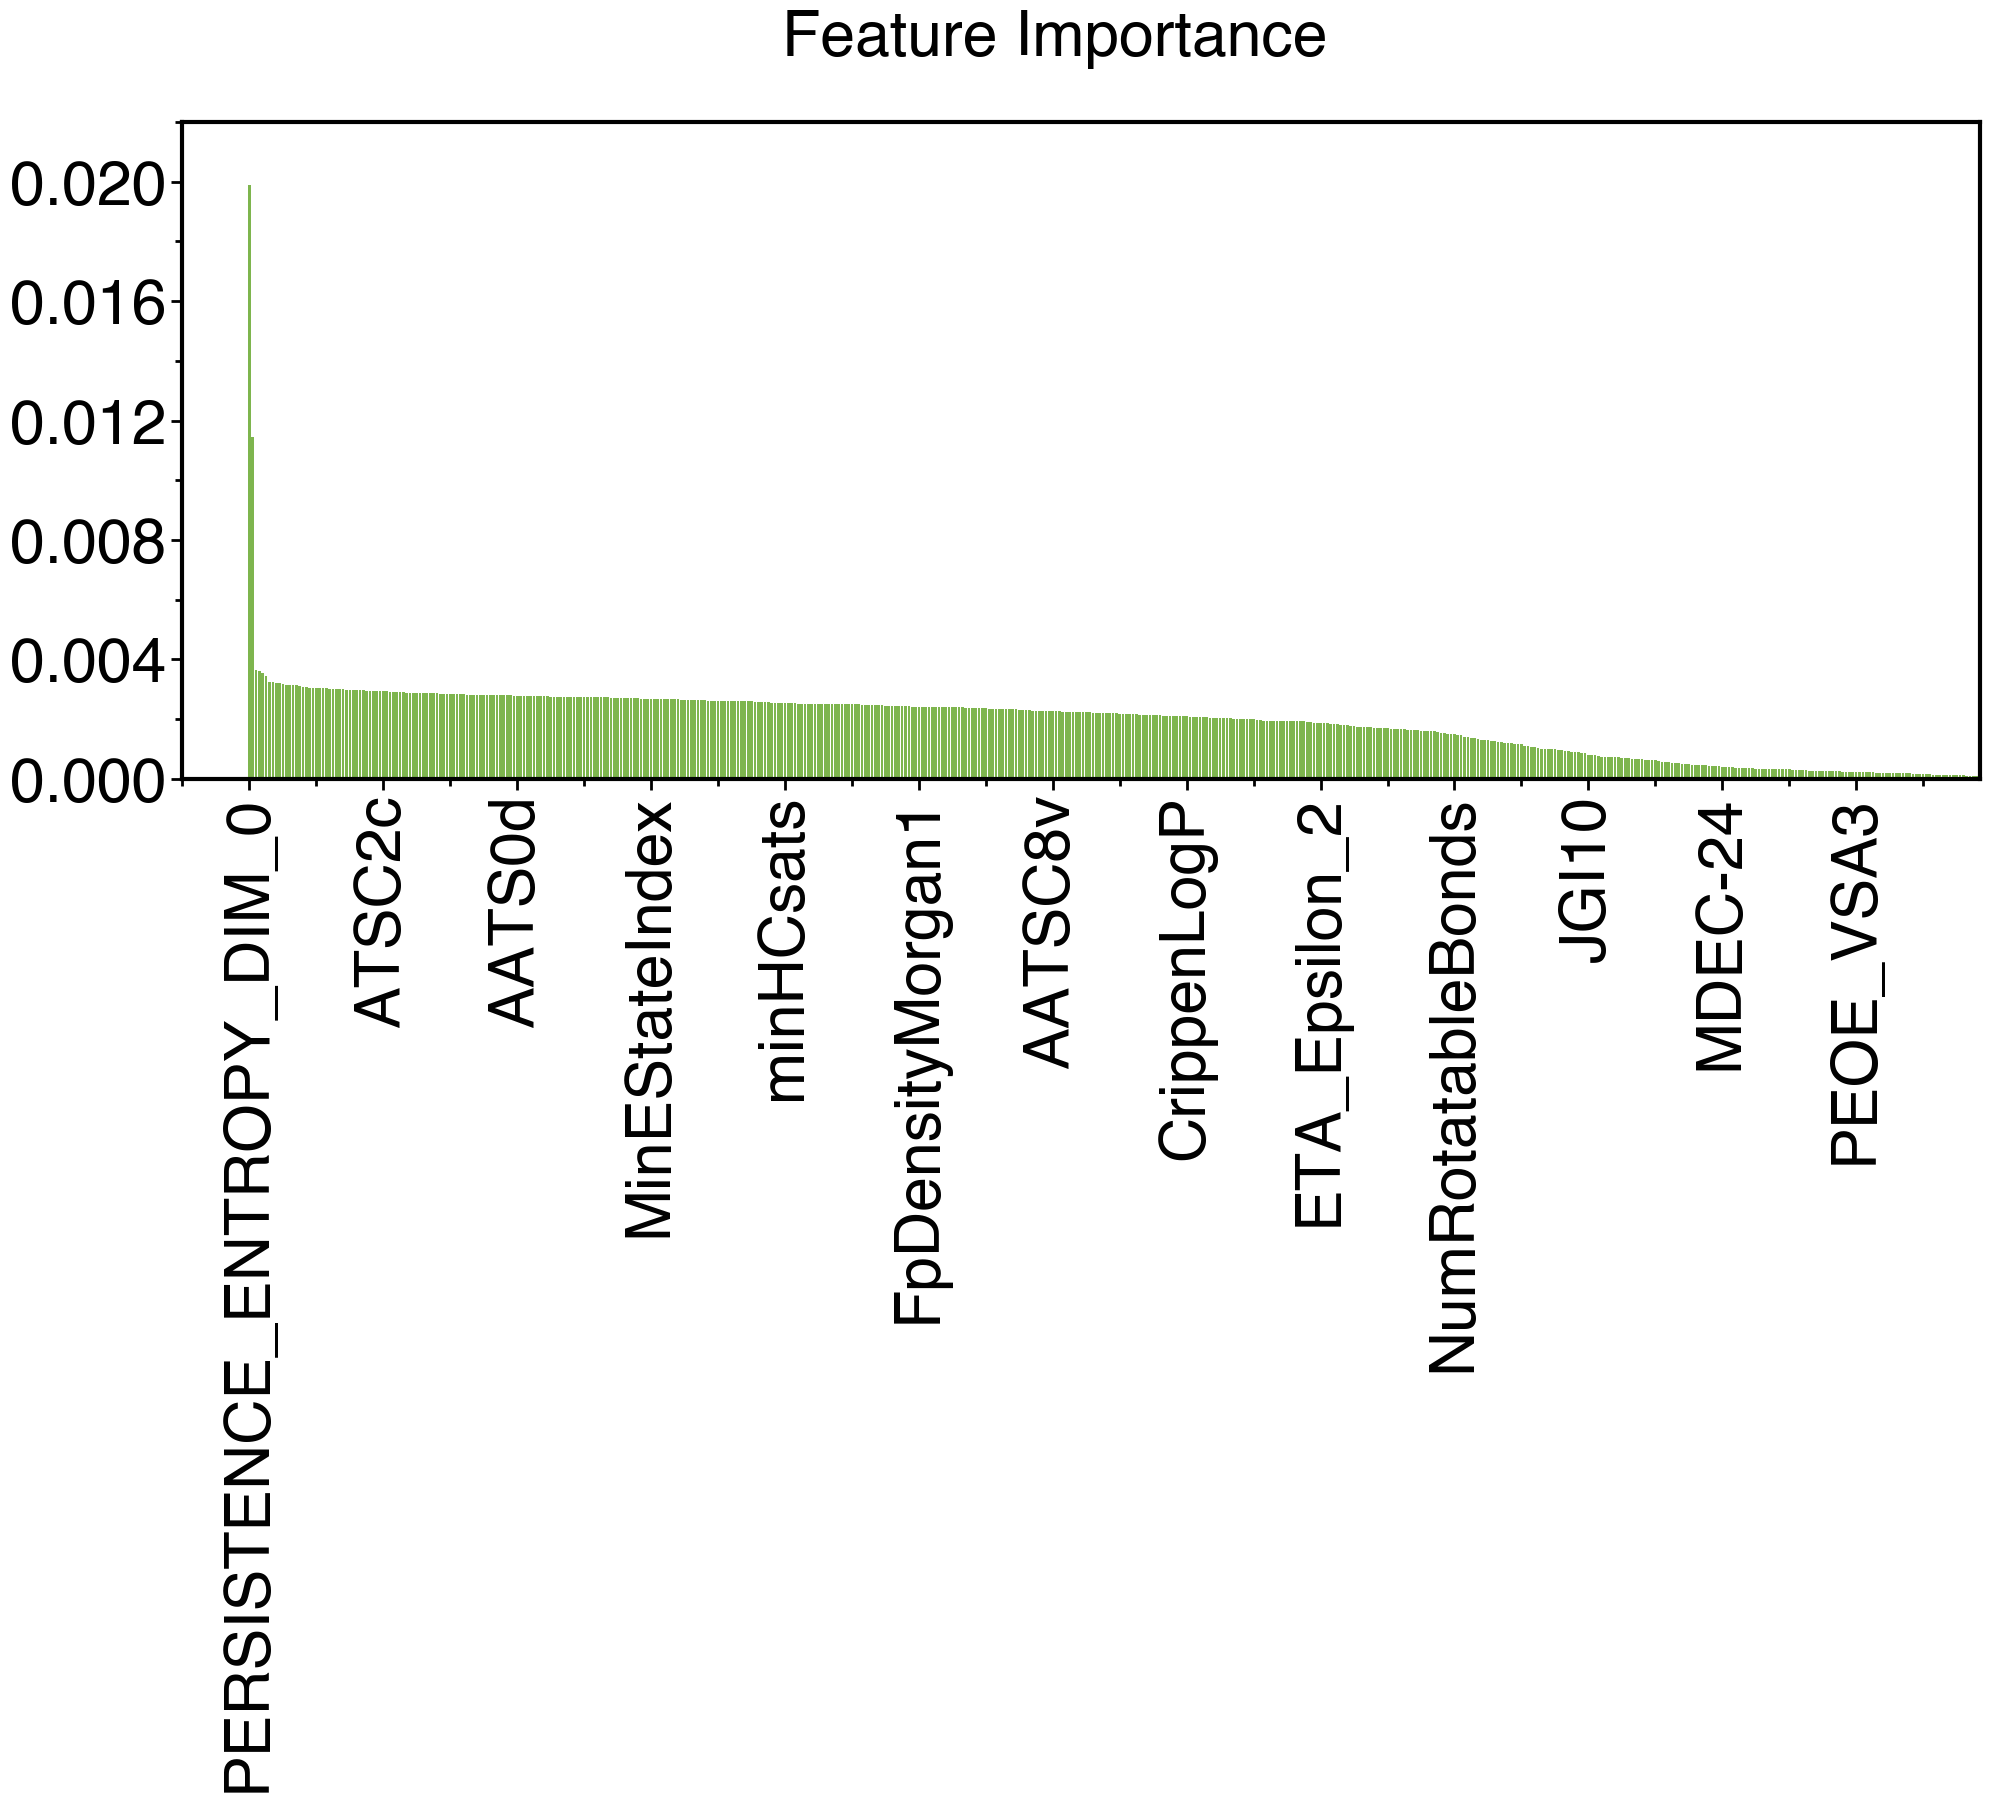

In [ ]:

%matplotlib
%pylab inline
c = '#7eb54e'

myfont = FontProperties(fname=r'/usr/local/lib/python3.10/dist-packages/matplotlib/mpl-data/fonts/ttf/Helvetica.ttf',size=45)
#plt.bar(range(X_train.shape[1]), importances[sorted_indices], align='center',color =c)
# Create a subplot
fig, ax = plt.subplots(1,1,figsize=(20, 17))

ax.bar(range(X_dcor.shape[1]), importances[sorted_indices], align='center',color =c)
#plt.xticks(range(0,1400,10), X.columns[sorted_indices], rotation=90)
n = 20  # Show every 10th label
plt.xticks(range(0, X_dcor.shape[1], n), X_dcor.columns[sorted_indices[::n]], rotation=90)

ax.xaxis.set_major_locator(MultipleLocator(40))
ax.xaxis.set_minor_locator(MultipleLocator(20))
ax.yaxis.set_major_locator(MultipleLocator(0.004))
ax.yaxis.set_minor_locator(MultipleLocator(0.002))
ax.tick_params(axis='y', right=False)
ax.tick_params(which='both', width=2)
ax.tick_params(which='major', length=8)
ax.tick_params(which='minor', length=5)
ax.grid(False)
plt.setp(ax, xlim=(-20,len(df_feature_K)), ylim=(0,0.022))
plt.setp(ax.get_xticklabels(), fontsize=20,fontproperties=myfont)
plt.setp(ax.get_yticklabels(), fontsize=20,fontproperties=myfont)

# change all spines
# Customize the spines
for spine in ax.spines.values():
    spine.set_linewidth(3)  # Set the linewidth
    spine.set_color('k')  # Set the color
    spine.set_linestyle('-')  # Set the linestyle
#plt.title('Feature Importance',fontproperties=myfont, fontsize=20)
fig.text(0.53, 1.03, 'Feature Importance', ha='center',fontproperties=myfont)
plt.tight_layout()
plt.show()

plot top 20 important features

Using matplotlib backend: agg
Populating the interactive namespace from numpy and matplotlib


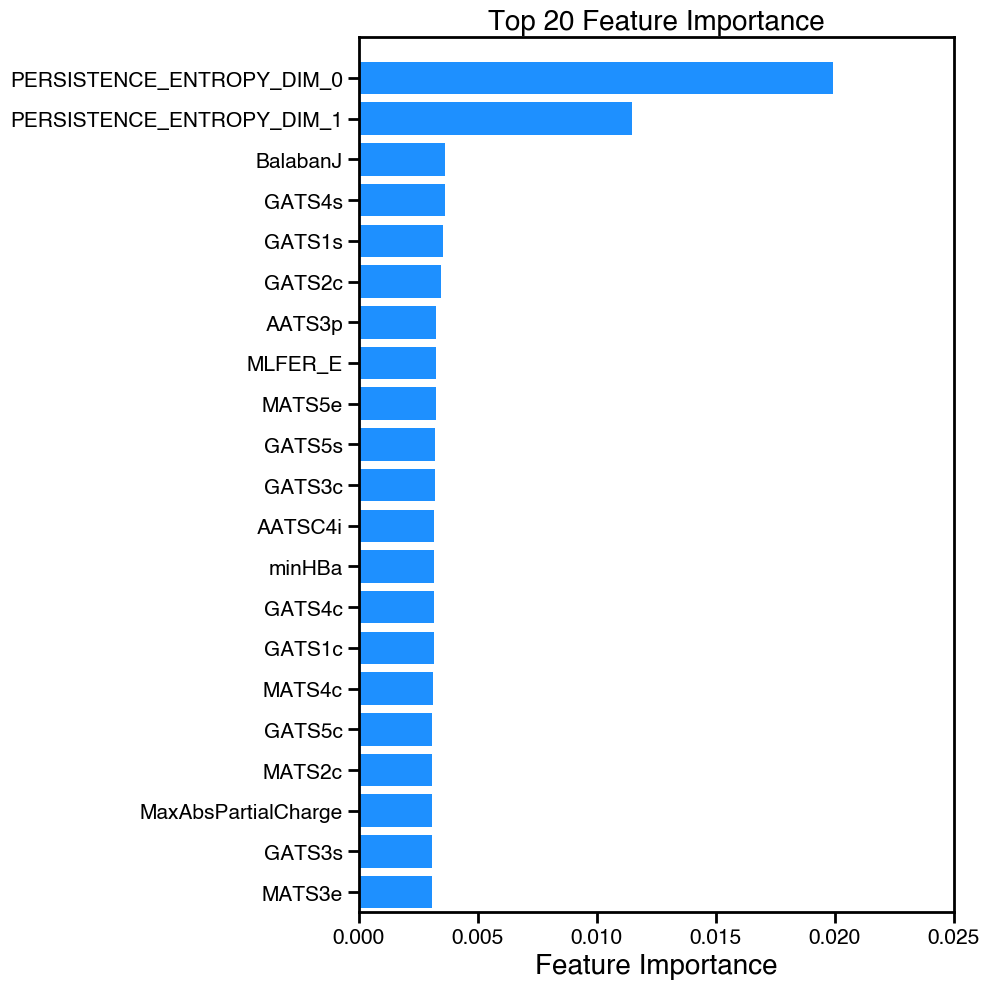

In [ ]:

%matplotlib
%pylab inline

myfont = FontProperties(fname=r'/usr/local/lib/python3.10/dist-packages/matplotlib/mpl-data/fonts/ttf/Helvetica.ttf',size=15)
#plt.bar(range(X_train.shape[1]), importances[sorted_indices], align='center',color =c)
# Create a subplot
fig, ax = plt.subplots(figsize=(10, 10))

ax.barh(range(X_dcor.shape[1]),importances[sorted_indices], align='center',color ='dodgerblue')
n = 1  # Show every 10th label
plt.yticks(range(0, X_dcor.shape[1], n), X_dcor.columns[sorted_indices[::n]])
#plt.tick_params(left = False, right = True , labelleft = False ,
#                labelbottom = True, bottom = False)

#ax.xaxis.set_major_locator(MultipleLocator(1))
#ax.xaxis.set_minor_locator(MultipleLocator(1))
#ax.yaxis.set_major_locator(MultipleLocator(0.002))
#ax.yaxis.set_minor_locator(MultipleLocator(0.001))
#ax.yaxis.tick_right()
ax.tick_params(which='both', width=2)
ax.tick_params(which='major', length=8)
ax.tick_params(which='minor', length=5)
ax.grid(False)
plt.setp(ax, ylim=(20.5,-1), xlim=(0,0.025))
plt.setp(ax.get_xticklabels(), fontsize=20,fontproperties=myfont)
plt.setp(ax.get_yticklabels(), fontsize=20,fontproperties=myfont)

# change all spines
# Customize the spines
for spine in ax.spines.values():
    spine.set_linewidth(2)  # Set the linewidth
    spine.set_color('k')  # Set the color
    spine.set_linestyle('-')  # Set the linestyle
plt.title('Top 20 Feature Importance',fontproperties=myfont, fontsize=20)
plt.xlabel('Feature Importance',fontproperties=myfont, fontsize=20)
#fig.text(-0.04, 0.75, 'Feature Importance', va='center', rotation='vertical',fontsize=30,fontproperties=myfont)
#fig.text(0.5, -0.03, 'Top 20 Features', ha='center',fontsize=30,fontproperties=myfont,rotation=180)
# Rotate the entire plot by 90 degrees
plt.tight_layout()
plt.show()

In [ ]:
# Extract the column names from df2
selected_columns = df_feature_K['feature'].tolist()
# Select columns from df based on the values in df2
#result_df = f_smile4[selected_columns]
result_df = X_dcor[selected_columns]
# Now, result_df contains only the selected columns from df
result_df.to_csv('f_clean_553_important.csv', index=False)
result_df

,PERSISTENCE_ENTROPY_DIM_0,PERSISTENCE_ENTROPY_DIM_1,BalabanJ,GATS4s,GATS1s,GATS2c,AATS3p,MLFER_E,MATS5e,GATS5s,...,nHBint2,n5aHRing,Xch-4dv,SdS,NsNH2,NumAromaticHeterocycles,nAcid,EState_VSA3,NdS,nT7Ring
0,3.947052,2.529469,3.157731,1.133733,0.734216,0.535776,1.424479,0.977,-0.006304,0.919942,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,3.424074,1.140838,3.224658,1.046224,1.108842,0.771470,1.364165,0.871,-0.011001,0.900704,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,3.067019,1.568200,3.585884,1.005796,0.978931,1.648034,1.177677,0.691,0.056605,0.940555,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,3.141797,1.336667,3.721251,1.189552,0.977675,1.347515,0.981226,0.259,-0.021125,0.671862,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1.585853,0.000000,6.520178,0.829164,1.273328,1.347527,0.948098,0.047,-0.086085,0.979782,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3904,3.463763,0.168566,6.393765,1.365878,0.611231,1.076683,1.019847,0.352,-0.065094,1.345014,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3905,2.910674,0.649751,3.488536,1.033808,1.097235,0.971529,1.030786,1.255,0.031362,1.031688,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3906,3.345647,1.552718,3.655531,1.936391,0.583110,0.935317,1.268906,0.752,0.096484,1.955591,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3907,2.553369,0.244144,3.384671,0.000000,1.221805,1.409049,0.754039,0.386,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
# Create new test data with same selected features
X_test_selected = f_testa[selected_columns]
# Convert the list to a DataFrame
df_selected_columns = pd.DataFrame(selected_columns)
# Save the DataFrame to a CSV file
df_selected_columns.to_csv('selected_columns.csv', index=False)

In [ ]:
X_test_selected.to_csv('f_test.csv', index=False)

In [ ]:
X_test_selected

,PERSISTENCE_ENTROPY_DIM_0,PERSISTENCE_ENTROPY_DIM_1,BalabanJ,GATS4s,GATS1s,GATS2c,AATS3p,MLFER_E,MATS5e,GATS5s,...,nHBint2,n5aHRing,Xch-4dv,SdS,NsNH2,NumAromaticHeterocycles,nAcid,EState_VSA3,NdS,nT7Ring
7,2.606195,0.000000,2.943085,0.480583,0.542498,0.864200,1.456032,1.517,-0.139158,1.037044,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
12,3.750266,2.446910,3.889911,0.609856,0.680761,0.657794,1.615138,0.978,-0.038043,0.911623,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
16,3.428716,0.924027,3.693644,1.333671,0.709824,1.106479,1.448221,1.068,-0.051871,1.123949,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
19,3.098960,0.000000,4.206977,1.974463,0.967644,0.501811,0.851284,0.279,0.469155,0.000000,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
26,3.054224,0.400528,2.687749,0.723827,0.558402,0.767707,1.390722,1.053,-0.068941,1.088890,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5185,3.164504,0.000000,6.480434,0.658301,1.089879,0.921409,1.018878,0.477,-0.033843,0.935117,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5190,3.261954,0.000000,6.152621,1.524410,0.802302,1.094696,0.965793,0.395,-0.102051,1.027241,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5194,3.208285,0.000000,6.685085,0.548138,1.072340,0.869389,0.961984,0.341,-0.014110,0.863234,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5208,2.853617,1.355357,6.347027,1.152078,0.919512,0.712562,1.031831,0.340,-0.444336,2.008782,...,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0


Test data after feature selection

In [ ]:
X_test_f = X_test[selected_columns]
X_test_f

,PERSISTENCE_ENTROPY_DIM_0,PERSISTENCE_ENTROPY_DIM_1,BalabanJ,GATS4s,GATS1s,GATS2c,AATS3p,MLFER_E,MATS5e,GATS5s,...,nHBint2,n5aHRing,Xch-4dv,SdS,NsNH2,NumAromaticHeterocycles,nAcid,EState_VSA3,NdS,nT7Ring
7,2.606195,0.000000,2.943085,0.480583,0.542498,0.864200,1.456032,1.517,-0.139158,1.037044,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
12,3.750266,2.446910,3.889911,0.609856,0.680761,0.657794,1.615138,0.978,-0.038043,0.911623,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
16,3.428716,0.924027,3.693644,1.333671,0.709824,1.106479,1.448221,1.068,-0.051871,1.123949,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
19,3.098960,0.000000,4.206977,1.974463,0.967644,0.501811,0.851284,0.279,0.469155,0.000000,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
26,3.054224,0.400528,2.687749,0.723827,0.558402,0.767707,1.390722,1.053,-0.068941,1.088890,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5185,3.164504,0.000000,6.480434,0.658301,1.089879,0.921409,1.018878,0.477,-0.033843,0.935117,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5190,3.261954,0.000000,6.152621,1.524410,0.802302,1.094696,0.965793,0.395,-0.102051,1.027241,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5194,3.208285,0.000000,6.685085,0.548138,1.072340,0.869389,0.961984,0.341,-0.014110,0.863234,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5208,2.853617,1.355357,6.347027,1.152078,0.919512,0.712562,1.031831,0.340,-0.444336,2.008782,...,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0


# ML part

## Nomalization


In [ ]:
# load the final dataset
result_df=pd.read_csv('f_clean_553_important.csv')
X_test_selected=pd.read_csv('f_test.csv')
y_train_a = pd.read_csv('y_train.csv')
y_test_a = pd.read_csv('y_test.csv')

Data scale

In [ ]:
from sklearn.preprocessing import MinMaxScaler
#scaler=StandardScaler()
scaler=MinMaxScaler()
X_train_a = scaler.fit_transform(result_df)
X_test_a = scaler.transform(X_test_selected)

In [ ]:
joblib.dump(scaler, 'scaler_ML.pkl')

['scaler_ML.pkl']

## KNN

Tuning hyperparameters for KNN

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.multioutput import MultiOutputClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import f1_score


estimator_KNN = KNeighborsClassifier(algorithm='auto',weights='distance')
parameters_KNN = {
    'n_neighbors': (1,5,10,15),
    'leaf_size': (20,40,1),
    'p': (1,2)
}
# with GridSearch

scoring = make_scorer(f1_score, average='micro')

search_KNN = GridSearchCV(
    estimator=estimator_KNN,
    param_grid=parameters_KNN,
    scoring = scoring,
    n_jobs = -1,
    cv = 5
)
search_KNN.fit(X_train_a, y_train_a)
# Print the best parameters
print(search_KNN.best_params_)

# Print the best score
print(search_KNN.best_score_)

best=search_KNN.best_params_
# save best as text file
with open('/content/drive/MyDrive/best.txt', 'w') as f:
    f.write(str(best))

{'leaf_size': 20, 'n_neighbors': 1, 'p': 1}
0.1708692600592231


KNN training

In [ ]:
knn = KNeighborsClassifier(n_neighbors=1,weights='distance',leaf_size=20,p=1)
#knn = KNeighborsClassifier(n_neighbors=15,weights='distance',leaf_size=20,p=1
# Use MultiOutputClassifier to handle multi-label classification
multi_output_classifier = MultiOutputClassifier(knn, n_jobs=-1)

# Train the multi-label model
#multi_output_classifier.fit(X_train_resampled, y_train_resampled)
multi_output_classifier.fit(X_train_a, y_train_a)
#knn.fit(X_train, y_train)
y_pred = multi_output_classifier.predict(X_test_a)

predictions = multi_output_classifier.predict(X_test_a)
print('F1-score:', f1_score(y_test_a, predictions, average="micro"))
print('Precision:',precision_score(y_test_a, predictions, average="micro"))
print('Recall:',recall_score(y_test_a, predictions, average="micro"))

## ROC
# Compute Area Under the Receiver Operating Characteristic Curve (ROC AUC) from prediction scores.
#https://scikit-learn.org/stable/modules/generated/sklearn.metrics.roc_auc_score.html
y_pred = multi_output_classifier.predict_proba(X_test_a)
# extract the positive columns for each output
y_pred = np.transpose([pred[:, 1] for pred in y_pred])
roc_auc_score(y_test_a, y_pred, average=None)
print("Test Micro roc auc score = ",roc_auc_score(y_test_a, y_pred, multi_class='ovr',average='micro'))
print("Test Macro roc auc score = ",roc_auc_score(y_test_a, y_pred, multi_class='ovr',average='macro'))

F1-score: 0.21957413557335417
Precision: 0.21175584024114544
Recall: 0.2279918864097363
Test Micro roc auc score =  0.603098634194273
Test Macro roc auc score =  0.5413569116810953


## DT

Tuning hyperparameters for DT

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import f1_score

from sklearn.metrics import make_scorer
from sklearn.multioutput import MultiOutputClassifier

DT_classifier = DecisionTreeClassifier(class_weight='balanced')
multi_output_classifier = MultiOutputClassifier(DT_classifier, n_jobs=-1)




param_grid = {
    'estimator__min_samples_split':[10,20,30],
    'estimator__max_depth': [None, 5,10,15],
    'estimator__min_samples_leaf': [5, 10,15,20]
}
scoring = make_scorer(f1_score, average='micro')
search = GridSearchCV(
    estimator=multi_output_classifier,
    param_grid=param_grid,
    scoring=scoring,
    n_jobs = -1,
    cv = 5
).fit(X_train_a, y_train_a)

print(search.best_params_)
print(search.best_score_)

{'estimator__max_depth': None, 'estimator__min_samples_leaf': 5, 'estimator__min_samples_split': 20}
0.17457192980649755


Training

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.multioutput import MultiOutputClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report

# Assuming X_train, y_train, X_test are your training features, training labels, and test features respectively
# y_train should be a binary matrix where each row corresponds to an instance and each column to a label

# Create a Random Forest classifier
DT_classifier =  DecisionTreeClassifier(class_weight='balanced',max_depth=None,min_samples_leaf=5, min_samples_split=20, random_state=42)#class_weight='balanced',

# Use MultiOutputClassifier to handle multi-label classification
multi_output_classifier = MultiOutputClassifier(DT_classifier, n_jobs=-1)

# Train the multi-label model
multi_output_classifier.fit(X_train_a, y_train_a)

# Make predictions
predictions = multi_output_classifier.predict(X_test_a)
print('F1-score:', f1_score(y_test_a, predictions, average="micro"))
print('Precision:',precision_score(y_test_a, predictions, average="micro"))
print('Recall:',recall_score(y_test_a, predictions, average="micro"))




## ROC
# Compute Area Under the Receiver Operating Characteristic Curve (ROC AUC) from prediction scores.
#https://scikit-learn.org/stable/modules/generated/sklearn.metrics.roc_auc_score.html
y_pred = multi_output_classifier.predict_proba(X_test_a)
# extract the positive columns for each output
y_pred = np.transpose([pred[:, 1] for pred in y_pred])
roc_auc_score(y_test_a, y_pred, average=None)
print("Test Micro roc auc score = ",roc_auc_score(y_test_a, y_pred, multi_class='ovr',average='micro'))
print("Test Macro roc auc score = ",roc_auc_score(y_test_a, y_pred, multi_class='ovr',average='macro'))

F1-score: 0.21447574868681357
Precision: 0.16157878507554732
Recall: 0.3188640973630832
Test Micro roc auc score =  0.6566329838741052
Test Macro roc auc score =  0.5556682305643124


## RF

Tuning hyperparameters for RF

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import f1_score
from sklearn.metrics import make_scorer
from sklearn.metrics import make_scorer
from sklearn.multioutput import MultiOutputClassifier

rf_classifier = RandomForestClassifier(class_weight='balanced')
multi_output_classifier = MultiOutputClassifier(rf_classifier, n_jobs=-1)

param_grid = {
    'estimator__n_estimators': [30, 35,38,45],
    'estimator__max_depth': [None, 5,10,15],
    'estimator__min_samples_leaf': [5, 10,15,20]
}
scoring = make_scorer(f1_score, average='micro')
search = GridSearchCV(
    estimator=multi_output_classifier,
    param_grid=param_grid,
    scoring=scoring,
    cv = 5
).fit(X_train_a, y_train_a)

print(search.best_params_)
print(search.best_score_)


{'estimator__max_depth': 10, 'estimator__min_samples_leaf': 15, 'estimator__n_estimators': 38}
0.24588361745526216


In [ ]:
best=search.best_params_
# save best as text file
with open('/content/drive/MyDrive/best.txt', 'w') as f:
    f.write(str(best))

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.multioutput import MultiOutputClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report

# Assuming X_train, y_train, X_test are your training features, training labels, and test features respectively
# y_train should be a binary matrix where each row corresponds to an instance and each column to a label

# Create a Random Forest classifier
rf_classifier = RandomForestClassifier(class_weight='balanced',max_depth=10,n_estimators=38, min_samples_leaf=15, random_state=42)#class_weight='balanced',

# Use MultiOutputClassifier to handle multi-label classification
multi_output_classifier = MultiOutputClassifier(rf_classifier, n_jobs=-1)

# Train the multi-label model
multi_output_classifier.fit(X_train_a, y_train_a)

# Make predictions
predictions = multi_output_classifier.predict(X_test_a)
print('F1-score:', f1_score(y_test_a, predictions, average="micro"))
print('Precision:',precision_score(y_test_a, predictions, average="micro"))
print('Recall:',recall_score(y_test_a, predictions, average="micro"))


## ROC
# Compute Area Under the Receiver Operating Characteristic Curve (ROC AUC) from prediction scores.
#https://scikit-learn.org/stable/modules/generated/sklearn.metrics.roc_auc_score.html
y_pred = multi_output_classifier.predict_proba(X_test_a)
# extract the positive columns for each output
y_pred = np.transpose([pred[:, 1] for pred in y_pred])
roc_auc_score(y_test_a, y_pred, average=None)
print("Test Micro roc auc score = ",roc_auc_score(y_test_a, y_pred, multi_class='ovr',average='micro'))
print("Test Macro roc auc score = ",roc_auc_score(y_test_a, y_pred, multi_class='ovr',average='macro'))

F1-score: 0.304972584609567
Precision: 0.2855878186968839
Recall: 0.3271805273833671
Test Micro roc auc score =  0.8660162266099634
Test Macro roc auc score =  0.7144077840350157


Save the model

In [ ]:
joblib.dump(multi_output_classifier, 'RF_ML.pkl')

['RF_ML.pkl']

### F1 score for each label

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1517: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_

<Figure size 1000x600 with 0 Axes>

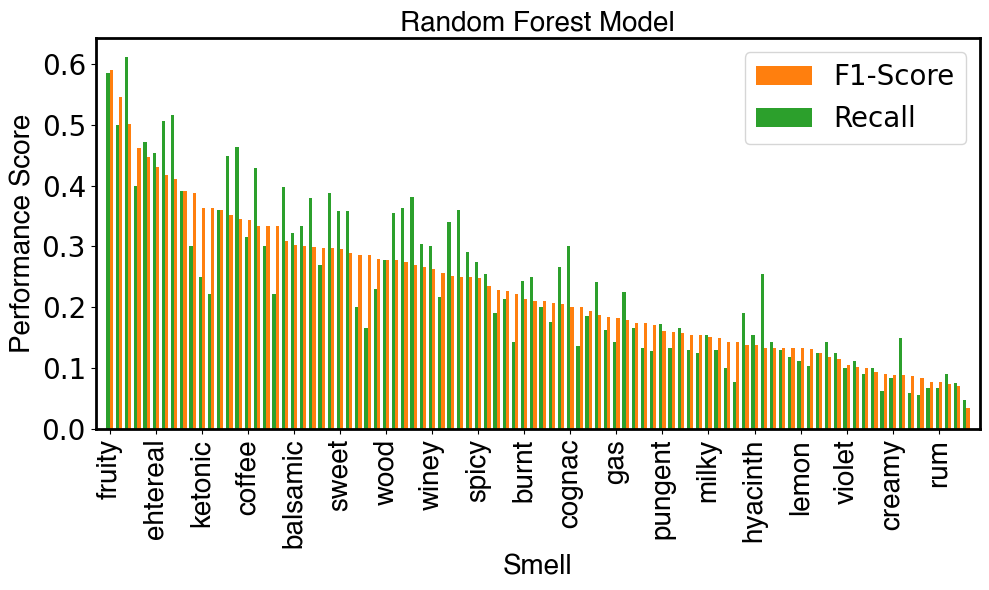

In [ ]:
myfont = FontProperties(fname=r'/usr/local/lib/python3.10/dist-packages/matplotlib/mpl-data/fonts/ttf/Helvetica.ttf',size=20)


score=classification_report(y_test_a,predictions,target_names= y_train_a.columns,output_dict=True)
# Extract class labels
class_names = list(score.keys())
# items to be removed
unwanted_num = {"micro avg",'macro avg','weighted avg','samples avg'}

class_names= [ele for ele in class_names if ele not in unwanted_num]

# Extract precision, recall, and F1-score for each class
precision = [score[class_name]['precision'] for class_name in class_names]
recall = [score[class_name]['recall'] for class_name in class_names]
f1_score = [score[class_name]['f1-score'] for class_name in class_names]

# # Sort precision, recall, and F1-score in descending order
sorted_indices = sorted(range(len(f1_score)), key=lambda k: (f1_score[k],recall[k],precision[k] ), reverse=True)
recall_sorted = [recall[i] for i in sorted_indices]
f1_score_sorted = [f1_score[i] for i in sorted_indices]
precision_sorted = [precision[i] for i in sorted_indices]


# Create the bar chart (similar to your existing code)
plt.figure(figsize=(10, 6))
fig, ax = plt.subplots(figsize =(10,6))
# Define width for the bars
width = 0.35
font=20
index = range(len(class_names))
bar1 = plt.bar([p + 2 * width for p in index], f1_score_sorted, width, label='F1-Score',color='C1')
bar2 = plt.bar([p + width for p in index], recall_sorted, width, label='Recall',color='C2')
#bar3 = plt.bar(index, precision_sorted, width, label='Precision')


plt.xlabel('Smell',fontsize=font,fontproperties=myfont)
plt.ylabel('Performance Score',fontsize=font,fontproperties=myfont)
plt.title('Random Forest Model',fontsize=font,fontproperties=myfont)
n = 5  # Show every 10th label
#plt.xticks(range(0, X_dcor.shape[1], n), X_dcor.columns[sorted_indices[::n]], rotation=90)

plt.xticks([p + 1.5 * width for p in index[::n]], [class_names[i] for i in sorted_indices[::n]])

plt.xticks(rotation=90,fontsize=15,fontproperties=myfont)
plt.yticks(fontsize=font)
#ax.tick_params(axis='both', labelsize=30,width=3, length=5)
ax.spines['bottom'].set_linewidth(2)
ax.spines['left'].set_linewidth(2)
ax.spines['right'].set_linewidth(2)
ax.spines['top'].set_linewidth(2)
plt.xlim(-1,95)
plt.legend(fontsize=font)

plt.tight_layout()
plt.show()

In [ ]:
#generate new dataframe, first column is auc_roc, second column is f1-score, column 0 is name of labels

import pandas as pd
auc_roc=roc_auc_score(y_test_a, y_pred, average=None)
# Create a dictionary with labels as keys and corresponding scores as values
scores = {'Label': y_train_a.columns, 'AUC-ROC': auc_roc, 'f1-score': f1_score}

# Create a Pandas DataFrame from the dictionary
df = pd.DataFrame(scores)
df_sorted = df.sort_values(by='f1-score', ascending=False)
# Print the DataFrame



AUC ROV for each label

### plot each auc roc score

In [ ]:
y_pred = multi_output_classifier.predict_proba(X_test_a)
# extract the positive columns for each output
y_pred = np.transpose([pred[:, 1] for pred in y_pred])
roc_auc_score(y_test_a, y_pred, average=None)
print("Test Micro roc auc score = ",roc_auc_score(y_test_a, y_pred, multi_class='ovr',average='micro'))
print("Test Macro roc auc score = ",roc_auc_score(y_test_a, y_pred, multi_class='ovr',average='macro'))

Test Micro roc auc score =  0.8660162266099634
Test Macro roc auc score =  0.7144077840350157


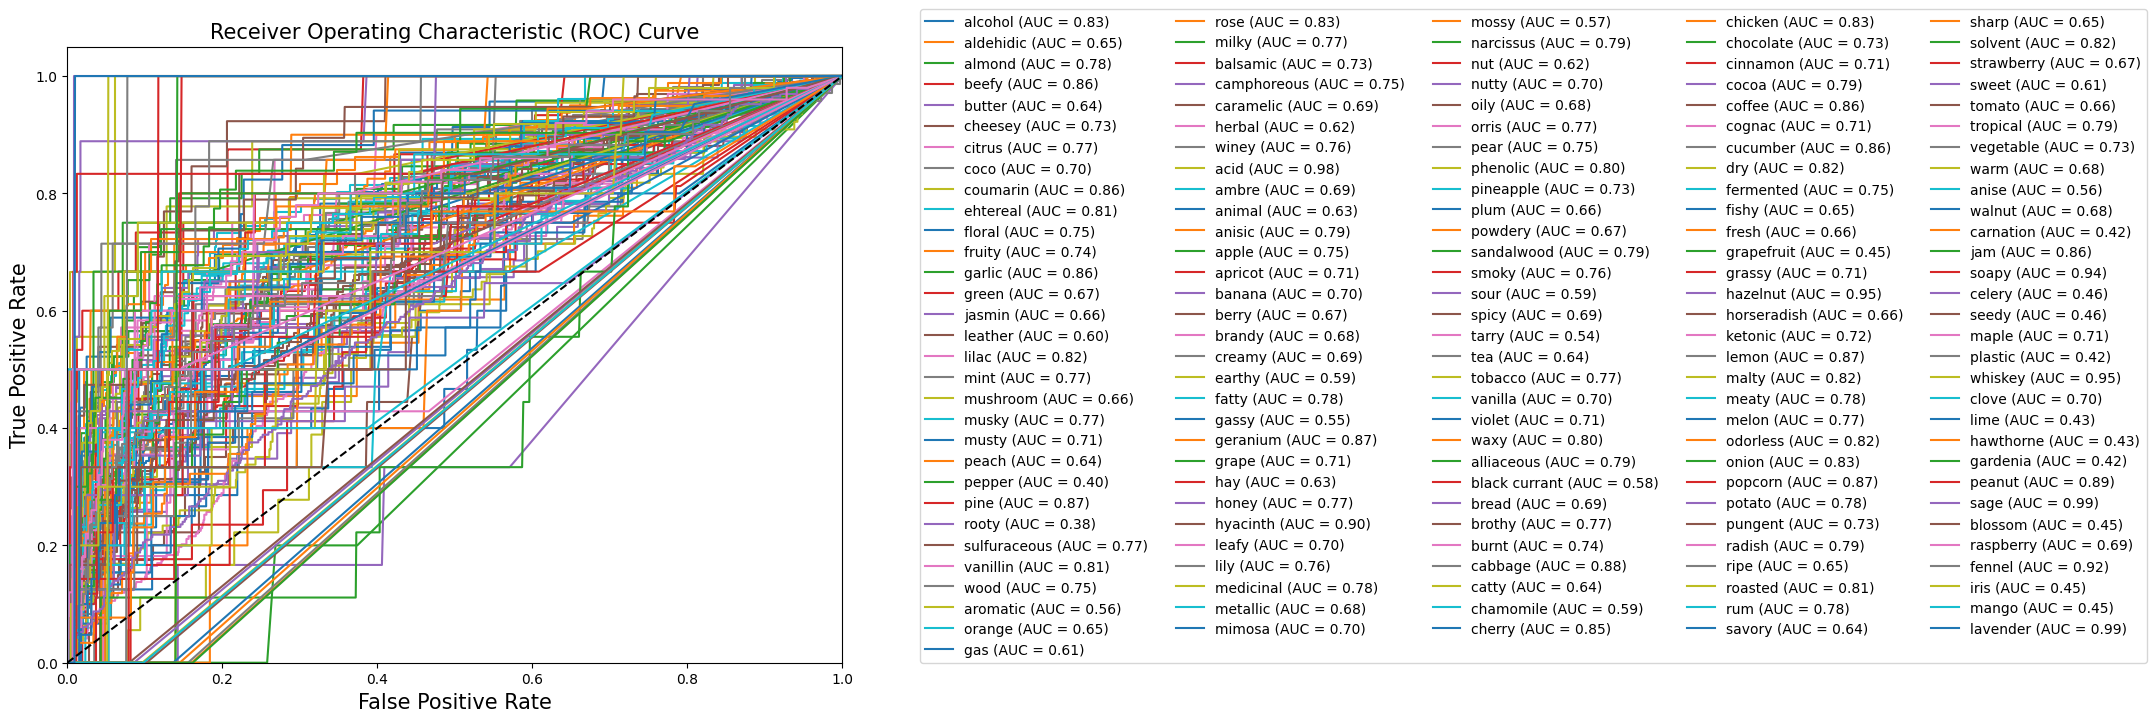

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve
font=15
class_names = y_train_a.columns
# Get the class probabilities for the test set
y_pred = multi_output_classifier.predict_proba(X_test_a)
y_pred = np.transpose([pred[:, 1] for pred in y_pred])
y_test_b=y_test_a.to_numpy()
n_outputs = y_test_a.shape[1]  # Number of outputs

# Calculate ROC curves and areas under the curve
fpr_list, tpr_list, roc_auc_list = [], [], []
for i in range(n_outputs):
    fpr, tpr, _ = roc_curve(y_test_b[:, i], y_pred[:, i])
    fpr_list.append(fpr)
    tpr_list.append(tpr)
    roc_auc_list.append(roc_auc_score(y_test_b[:, i], y_pred[:, i]))

# Plot ROC curves

# Plot ROC curves
plt.figure(figsize=(10, 8))
for i in range(n_outputs):
    plt.plot(fpr_list[i], tpr_list[i], label=f'{class_names[i]} (AUC = {roc_auc_list[i]:.2f})')



plt.plot([0, 1], [0, 1], 'k--')  # Diagonal line (random classifier)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate',fontsize=font)
plt.ylabel('True Positive Rate',fontsize=font)
plt.title('Receiver Operating Characteristic (ROC) Curve',fontsize=font)
plt.legend(loc=(1.1, 0),ncol = 5)
plt.show()

### average AUC-ROC

Using matplotlib backend: agg
Populating the interactive namespace from numpy and matplotlib


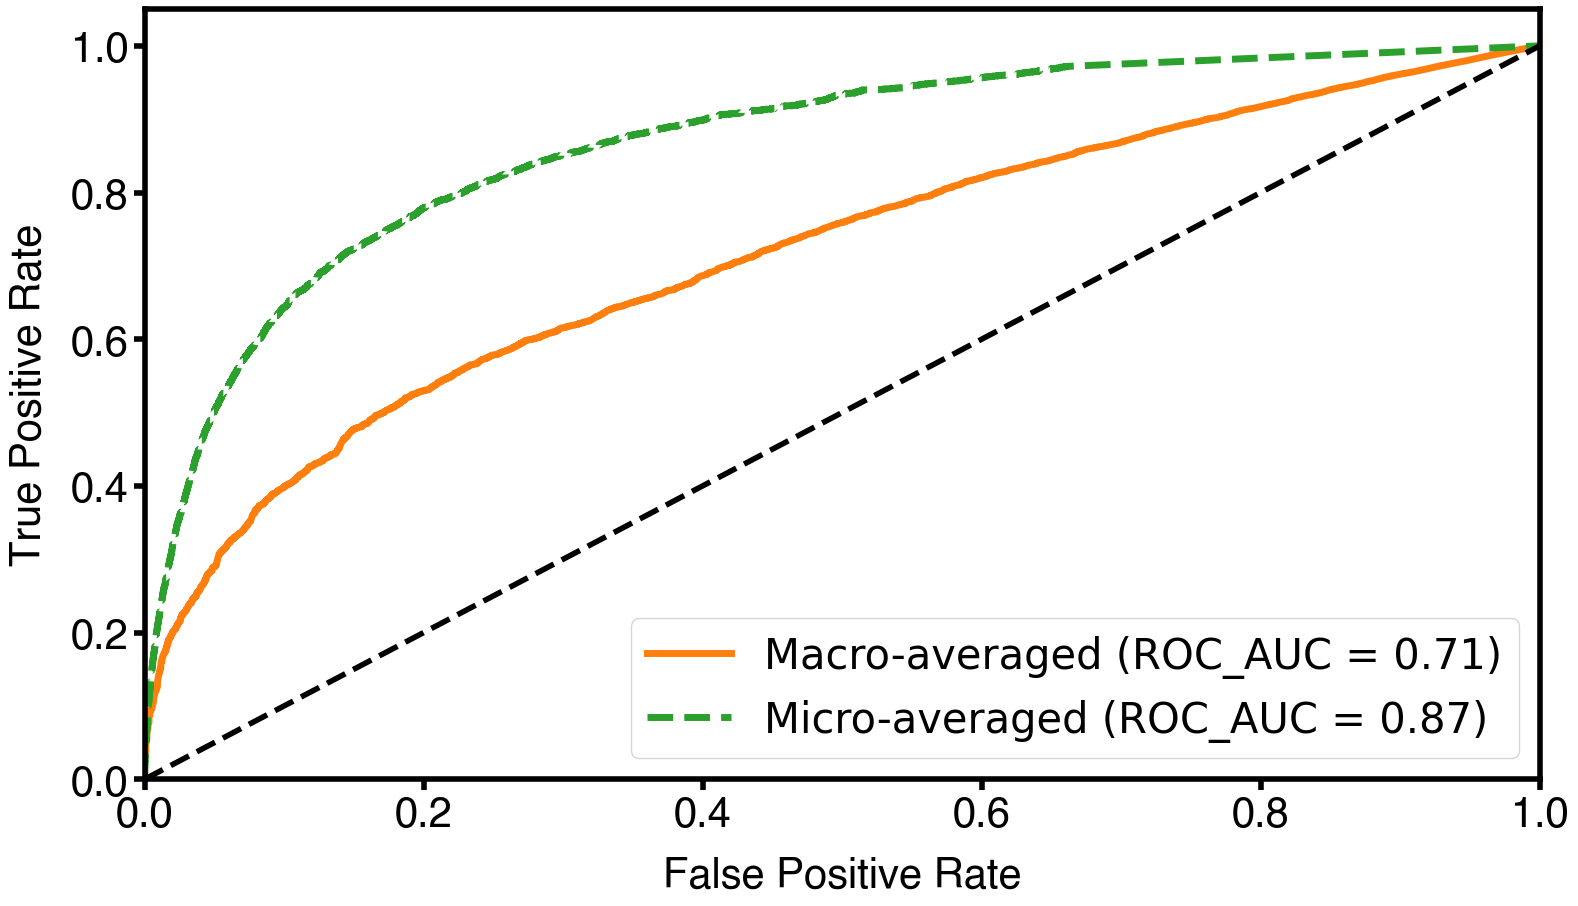

In [ ]:
%matplotlib
%pylab inline

myfont = FontProperties(fname=r'/usr/local/lib/python3.10/dist-packages/matplotlib/mpl-data/fonts/ttf/Helvetica.ttf',size=30)

font=30
# Plot ROC curves
y_pred = multi_output_classifier.predict_proba(X_test_a)
y_pred = np.transpose([pred[:, 1] for pred in y_pred])
y_test_b=y_test_a.to_numpy()
# Calculate the micro-averaged ROC curve
fpr_micro, tpr_micro, _ = roc_curve(y_test_b.ravel(), y_pred.ravel(), pos_label=1)
roc_auc_micro = roc_auc_score(y_test_b, y_pred, average='micro')


# Calculate the macro-averaged ROC curve
all_fpr = np.unique(np.concatenate(fpr_list))
mean_tpr = np.zeros_like(all_fpr)
for i in range(n_outputs):
    mean_tpr += np.interp(all_fpr, fpr_list[i], tpr_list[i])
mean_tpr /= n_outputs
# Calculate ROC curves and areas under the curve
fpr_list, tpr_list, roc_auc_list = [], [], []
for i in range(n_outputs):
    fpr, tpr, _ = roc_curve(y_test_b[:, i], y_pred[:, i])
    fpr_list.append(fpr)
    tpr_list.append(tpr)
    roc_auc_list.append(roc_auc_score(y_test_b[:, i], y_pred[:, i]))
# Calculate the macro-averaged AUC
roc_auc_macro = auc(all_fpr, mean_tpr)


#plt.figure(figsize=(16, 10))
fig, ax = plt.subplots(figsize =(18,10))
plt.plot(all_fpr, mean_tpr, label=f'Macro-averaged (ROC_AUC = {roc_auc_macro:.2f})',linestyle='-', linewidth=5,color='C1')
plt.plot(fpr_micro, tpr_micro, label=f'Micro-averaged (ROC_AUC = {roc_auc_micro:.2f})',linestyle='--', linewidth=5,color='C2')
plt.plot([0, 1], [0, 1], 'k--',linewidth=4)  # Diagonal line (random classifier)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.yticks(fontsize=font,fontproperties=myfont)
plt.xticks(fontsize=font,fontproperties=myfont)
plt.xlabel('False Positive Rate',fontsize=font,fontproperties=myfont,labelpad=15)
plt.ylabel('True Positive Rate',fontsize=font,fontproperties=myfont,labelpad=15)
#plt.title('Receiver Operating Characteristic (ROC) Curve',fontsize=font,fontproperties=myfont,y=1.05)
plt.legend(loc="lower right",fontsize=font)
ax.tick_params(axis='both', labelsize=font,width=4, length=8)
ax.spines['bottom'].set_linewidth(4)
ax.spines['left'].set_linewidth(4)
ax.spines['right'].set_linewidth(4)
ax.spines['top'].set_linewidth(4)
plt.show()

# Evaluation


https://machinelearningmastery.com/how-to-save-and-load-models-and-data-preparation-in-scikit-learn-for-later-use/

## Validation data pre-processing
 make use the new data has the same features (columns)

### 1. Load the model

In [ ]:
label = pd.read_csv('/content/y_train.csv') # label name
label_name =label.columns

sel_columns=pd.read_csv('/content/selected_columns.csv')  # the same features (columns)
selected_columns = sel_columns.iloc[:,0]

# load data scale pkl
scaler_ML= joblib.load('/content/scaler_ML.pkl')
# Load RF model
RF_ML= joblib.load('/content/RF_ML.pkl')

### 2. Validation dataset

In [ ]:
# load validation features
val_fea=pd.read_excel('/content/val_feature.xlsx')
val_fea

,CommonCID,MaxEStateIndex,MinEStateIndex,MaxAbsEStateIndex,MinAbsEStateIndex,qed,MolWt,HeavyAtomMolWt,ExactMolWt,NumValenceElectrons,...,TSRW10,WPath,WPol,Zagreb1,Zagreb2,mZagreb1,mZagreb2,PERSISTENCE_ENTROPY_DIM_0,PERSISTENCE_ENTROPY_DIM_1,PERSISTENCE_ENTROPY_DIM_2
0,53943254,8.574535,-4.695390,8.574535,1.064418,0.677712,206.329,184.153,206.167065,84,...,45.272021,428,16,64,68,4.972222,3.750000,3.498678,1.257946,0.000000
1,10060281,11.698710,-3.111414,11.698710,0.200433,0.532980,287.315,270.179,287.115758,110,...,53.717695,11000000277,25,94,104,8.305556,5.138889,3.404382,0.648781,0.000000
2,95227,11.952612,-4.874911,11.952612,2.499898,0.651071,198.306,176.130,198.161980,82,...,44.737735,336,17,64,70,5.944444,3.277778,3.800152,1.815087,0.507628
3,75208,8.252824,-3.982601,8.252824,1.306458,0.645892,178.275,160.131,178.135765,72,...,44.614117,228,19,66,75,7.006944,2.722222,3.532047,2.105791,1.511447


Data pre-procession

In [ ]:
val_fea_selected = val_fea[selected_columns]
val_fea_b = scaler_ML.transform(val_fea_selected)
val_fea_b

array([[6.92225757e-01, 3.24440501e-01, 4.19771217e-01, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [6.73569029e-01, 1.67328869e-01, 9.63315820e-08, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [7.51873451e-01, 4.68134447e-01, 4.26984582e-01, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [6.98827951e-01, 5.43110765e-01, 4.55568745e-01, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00]])

### 3. Prediction

In [ ]:
V_p = RF_ML.predict(val_fea_b)
V_p_a=pd.DataFrame(V_p, columns = y_train_a.columns)
V_p_a

,alcohol,aldehidic,almond,beefy,butter,cheesey,citrus,coco,coumarin,ehtereal,...,hawthorne,gardenia,peanut,sage,blossom,raspberry,fennel,iris,mango,lavender
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
V_p_a['Smell'] = (V_p_a.stack()
   .loc[lambda x: x>0]
   .reset_index()
   .groupby('level_0')
   .agg({'level_1':list})
)
V_p_as=V_p_a[['Smell']]
V_p_as

,Smell
0,"[floral, rose, herbal]"
1,"[floral, balsamic]"
2,"[floral, fruity, wood, herbal]"
3,[wood]


In [ ]:
val_true=pd.read_csv('/content/val_label2.csv')
val_true.iloc[:,-1]

0    ['floral', 'green', 'herbal', 'oily']
1                   ['floral', 'balsamic']
2                               ['fruity']
3                       ['wood', 'animal']
Name: TRUE, dtype: object

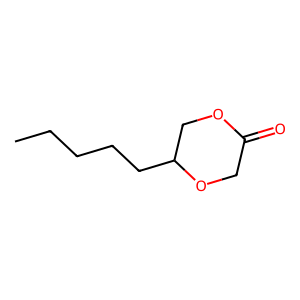

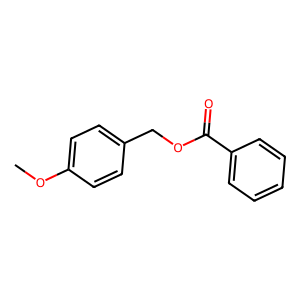

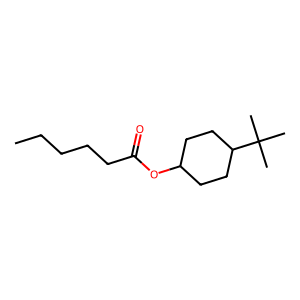

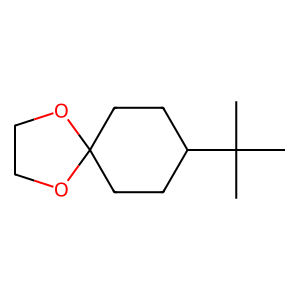

In [ ]:
# Generate RDKit molecule objects from SMILES strings
from rdkit import Chem
from rdkit.Chem import Draw

molecules = [Chem.MolFromSmiles(smi) for smi in val_true['Smell']]
# Draw the molecules
images = [Draw.MolToImage(mol) for mol in molecules]

# Display the images
for img in images:
    display(img)

Option

In [ ]:
# Extract a specific row from df1 to use as new column headers (e.g., the first row)
#nan_columns=pd.read_csv('/content/nan_columns.csv')
#common_columns = nan_columns.iloc[:,0]
#sel_columns=pd.read_csv('/content/selected_columns.csv')
#selected_columns = sel_columns.iloc[:,0]
#loaded_selector = joblib.load('selector.pkl')
#loaded_dcor_tr = joblib.load('dcor_tr.pkl')
#scaler_ML= joblib.load('/content/scaler_ML.pkl')